# Machine Learning-Based Remaining Useful Life Prediction of Aircraft Engines Using Adaptive Ensemble Techniques


**Dataset**: NASA C-MAPSS (FD001, FD002, FD003, FD004)  
**Novel Contributions**:
1. **Adaptive Weighted Ensemble** - softmax-based + life-stage adaptive model weighting (Early / Mid / Late)
2. **Operating Condition-Aware Modeling** - PCA + KMeans clustering
3. **Uncertainty-Aware RUL Prediction** - conformal prediction intervals


## Phase 0: Verify Libraries (Kaggle has these pre-installed)

In [1]:
# Kaggle has all required libraries pre-installed
# Just verify versions
import xgboost as xgb
import lightgbm as lgb
import sklearn
import numpy as np
import pandas as pd
print(f'XGBoost  : {xgb.__version__}')
print(f'LightGBM : {lgb.__version__}')
print(f'Sklearn  : {sklearn.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Pandas   : {pd.__version__}')
print('\nAll libraries available.')

XGBoost  : 3.2.0
LightGBM : 4.6.0
Sklearn  : 1.6.1
NumPy    : 2.0.2
Pandas   : 2.3.3

All libraries available.


In [2]:
# Check dataset path on Kaggle
# Run this cell first to confirm the exact folder structure
import os
print('Available input files:')
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Available input files:
/kaggle/input/datasets/anshulv03/cmapssdata/RUL_FD002.txt
/kaggle/input/datasets/anshulv03/cmapssdata/test_FD003.txt
/kaggle/input/datasets/anshulv03/cmapssdata/Damage Propagation Modeling.pdf
/kaggle/input/datasets/anshulv03/cmapssdata/readme.txt
/kaggle/input/datasets/anshulv03/cmapssdata/train_FD003.txt
/kaggle/input/datasets/anshulv03/cmapssdata/test_FD004.txt
/kaggle/input/datasets/anshulv03/cmapssdata/train_FD004.txt
/kaggle/input/datasets/anshulv03/cmapssdata/test_FD002.txt
/kaggle/input/datasets/anshulv03/cmapssdata/train_FD001.txt
/kaggle/input/datasets/anshulv03/cmapssdata/train_FD002.txt
/kaggle/input/datasets/anshulv03/cmapssdata/RUL_FD001.txt
/kaggle/input/datasets/anshulv03/cmapssdata/RUL_FD004.txt
/kaggle/input/datasets/anshulv03/cmapssdata/RUL_FD003.txt
/kaggle/input/datasets/anshulv03/cmapssdata/test_FD001.txt


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE = {
    'primary' : '#1C3557',
    'accent'  : '#E84855',
    'mid'     : '#3A86FF',
    'light'   : '#8ECAE6',
    'gold'    : '#F4A261',
    'green'   : '#2EC4B6',
    'purple'  : '#7B2D8B',
    'bg'      : '#F8F9FA',
}

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Phase 1: Data Loading

In [4]:
COL_NAMES = (
    ['engine_id', 'cycle'] +
    [f'op_{i}' for i in range(1, 4)] +
    [f's{i}' for i in range(1, 22)]
)

DROP_SENSORS  = ['s1','s5','s6','s10','s16','s18','s19','op_1','op_2','op_3']
SUBSETS       = ['FD001','FD002','FD003','FD004']
RUL_THRESHOLD = 130
WINDOW        = 5
N_CLUSTERS    = 3
N_PCA         = 10
BIAS_ALPHA    = 0.35     # FIX: increased from 0.30 to fix FD001 adaptive gap

# ── Kaggle data path ───────────────────────────────────────────────
# After running Phase 0 cell 2, check the exact path printed
# and update DATA_PATH below if different
DATA_PATH = '/kaggle/input/datasets/anshulv03/cmapssdata'

# Output path for saving files on Kaggle
OUTPUT_PATH = '/kaggle/working'


def load_dataset(subset, data_path=DATA_PATH):
    def read(fname):
        return pd.read_csv(
            os.path.join(data_path, fname),
            sep=r'\s+', header=None, names=COL_NAMES
        )
    train = read(f'train_{subset}.txt')
    test  = read(f'test_{subset}.txt')
    rul   = pd.read_csv(
        os.path.join(data_path, f'RUL_{subset}.txt'),
        sep=r'\s+', header=None, names=['RUL_true']
    )
    return train, test, rul


datasets = {}
for s in SUBSETS:
    tr, te, rul = load_dataset(s)
    datasets[s] = {'train': tr, 'test': te, 'rul': rul}
    print(f'{s} — train: {tr.shape}, test: {te.shape}, '
          f'train engines: {tr.engine_id.nunique()}, '
          f'test engines: {te.engine_id.nunique()}')

print('\nAll datasets loaded.')

FD001 — train: (20631, 26), test: (13096, 26), train engines: 100, test engines: 100
FD002 — train: (53759, 26), test: (33991, 26), train engines: 260, test engines: 259
FD003 — train: (24720, 26), test: (16596, 26), train engines: 100, test engines: 100
FD004 — train: (61249, 26), test: (41214, 26), train engines: 249, test engines: 248

All datasets loaded.


---
## Phase 2: Exploratory Data Analysis (EDA)

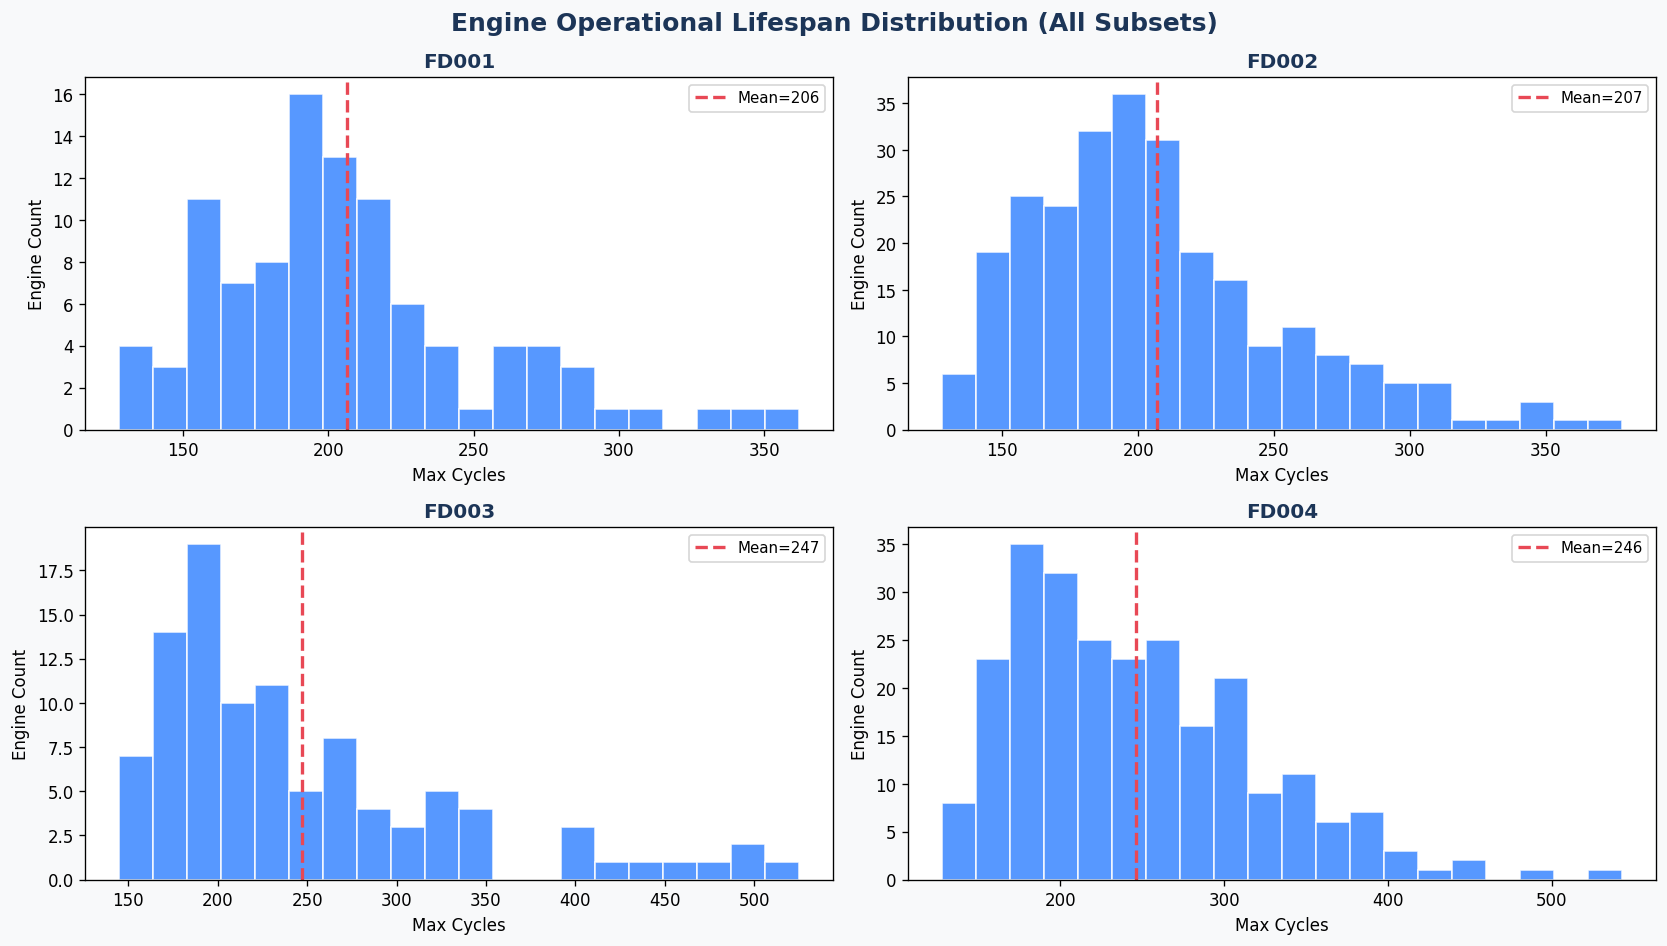

Saved: fig_engine_lifespan.png


In [5]:
# ── 2.1 Engine lifespan distribution ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor=PALETTE['bg'])
fig.suptitle('Engine Operational Lifespan Distribution (All Subsets)',
             fontsize=15, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    df = datasets[s]['train']
    max_cycles = df.groupby('engine_id')['cycle'].max()
    ax.hist(max_cycles, bins=20, color=PALETTE['mid'],
            edgecolor='white', alpha=0.85)
    ax.axvline(max_cycles.mean(), color=PALETTE['accent'], lw=2,
               linestyle='--', label=f'Mean={max_cycles.mean():.0f}')
    ax.set_title(s, fontweight='bold', color=PALETTE['primary'])
    ax.set_xlabel('Max Cycles')
    ax.set_ylabel('Engine Count')
    ax.legend(fontsize=9)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_engine_lifespan.png', bbox_inches='tight')
plt.show()
print('Saved: fig_engine_lifespan.png')

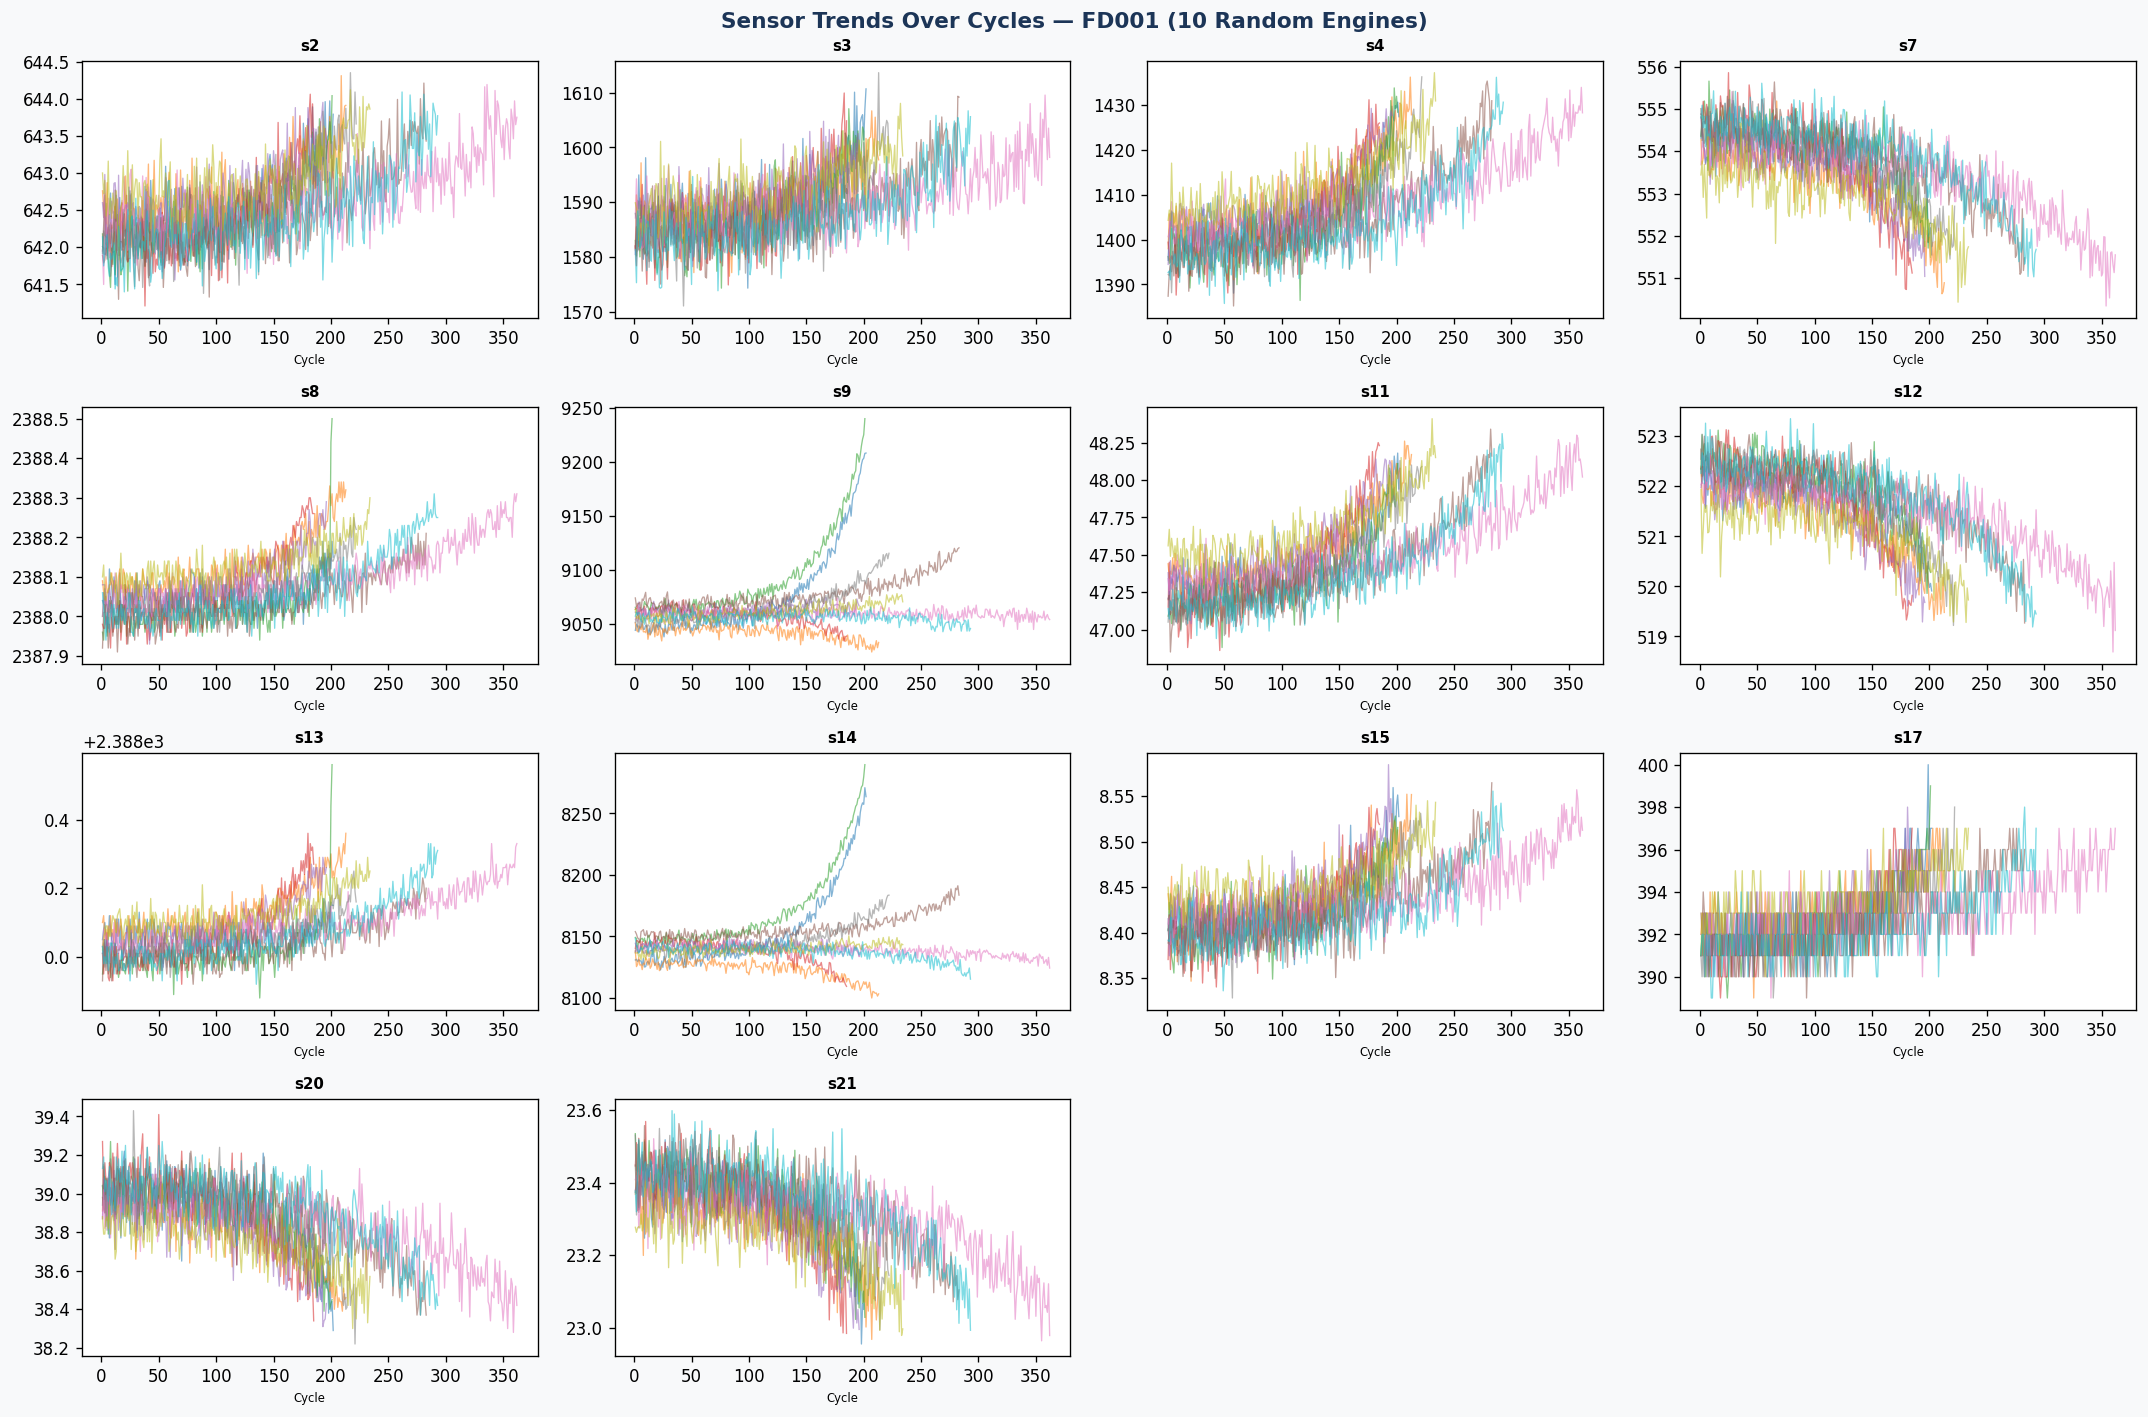

Saved: fig_sensor_trends.png


In [6]:
# ── 2.2 Sensor trends (FD001, 10 random engines) ───────────────────
df_fd1  = datasets['FD001']['train']
SENSORS = [c for c in df_fd1.columns
           if c.startswith('s') and c not in DROP_SENSORS]

rng = np.random.default_rng(42)
sample_engines = rng.choice(df_fd1.engine_id.unique(), 10, replace=False)

ncols = 4
nrows = (len(SENSORS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*3),
                          facecolor=PALETTE['bg'])
fig.suptitle('Sensor Trends Over Cycles — FD001 (10 Random Engines)',
             fontsize=13, fontweight='bold', color=PALETTE['primary'])

for ax, sensor in zip(axes.flatten(), SENSORS):
    for eid in sample_engines:
        sub = df_fd1[df_fd1.engine_id == eid]
        ax.plot(sub['cycle'], sub[sensor], alpha=0.55, linewidth=0.8)
    ax.set_title(sensor, fontsize=9, fontweight='bold')
    ax.set_xlabel('Cycle', fontsize=7)
    ax.set_facecolor('white')

for ax in axes.flatten()[len(SENSORS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_sensor_trends.png', bbox_inches='tight')
plt.show()
print('Saved: fig_sensor_trends.png')

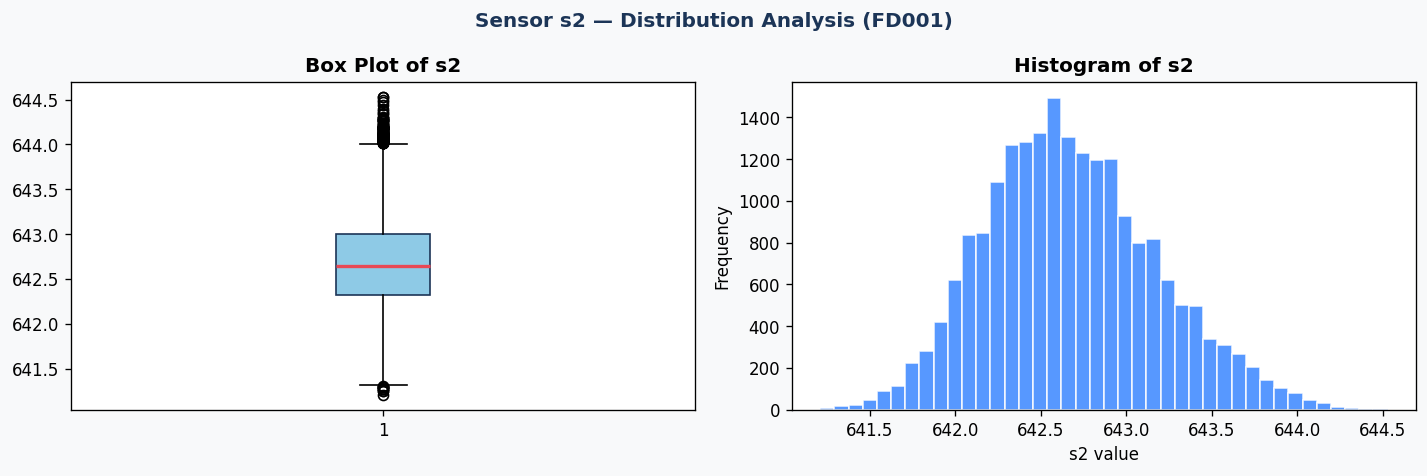

Saved: fig_s2_distribution.png


In [7]:
# ── 2.3 Boxplot + Histogram for sensor s2 (FD001) ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), facecolor=PALETTE['bg'])
fig.suptitle('Sensor s2 — Distribution Analysis (FD001)',
             fontweight='bold', color=PALETTE['primary'])

ax1.boxplot(df_fd1['s2'].dropna(), patch_artist=True,
            boxprops=dict(facecolor=PALETTE['light'],
                          color=PALETTE['primary']),
            medianprops=dict(color=PALETTE['accent'], linewidth=2))
ax1.set_title('Box Plot of s2', fontweight='bold')
ax1.set_facecolor('white')

ax2.hist(df_fd1['s2'].dropna(), bins=40,
         color=PALETTE['mid'], edgecolor='white', alpha=0.85)
ax2.set_title('Histogram of s2', fontweight='bold')
ax2.set_xlabel('s2 value')
ax2.set_ylabel('Frequency')
ax2.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_s2_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig_s2_distribution.png')

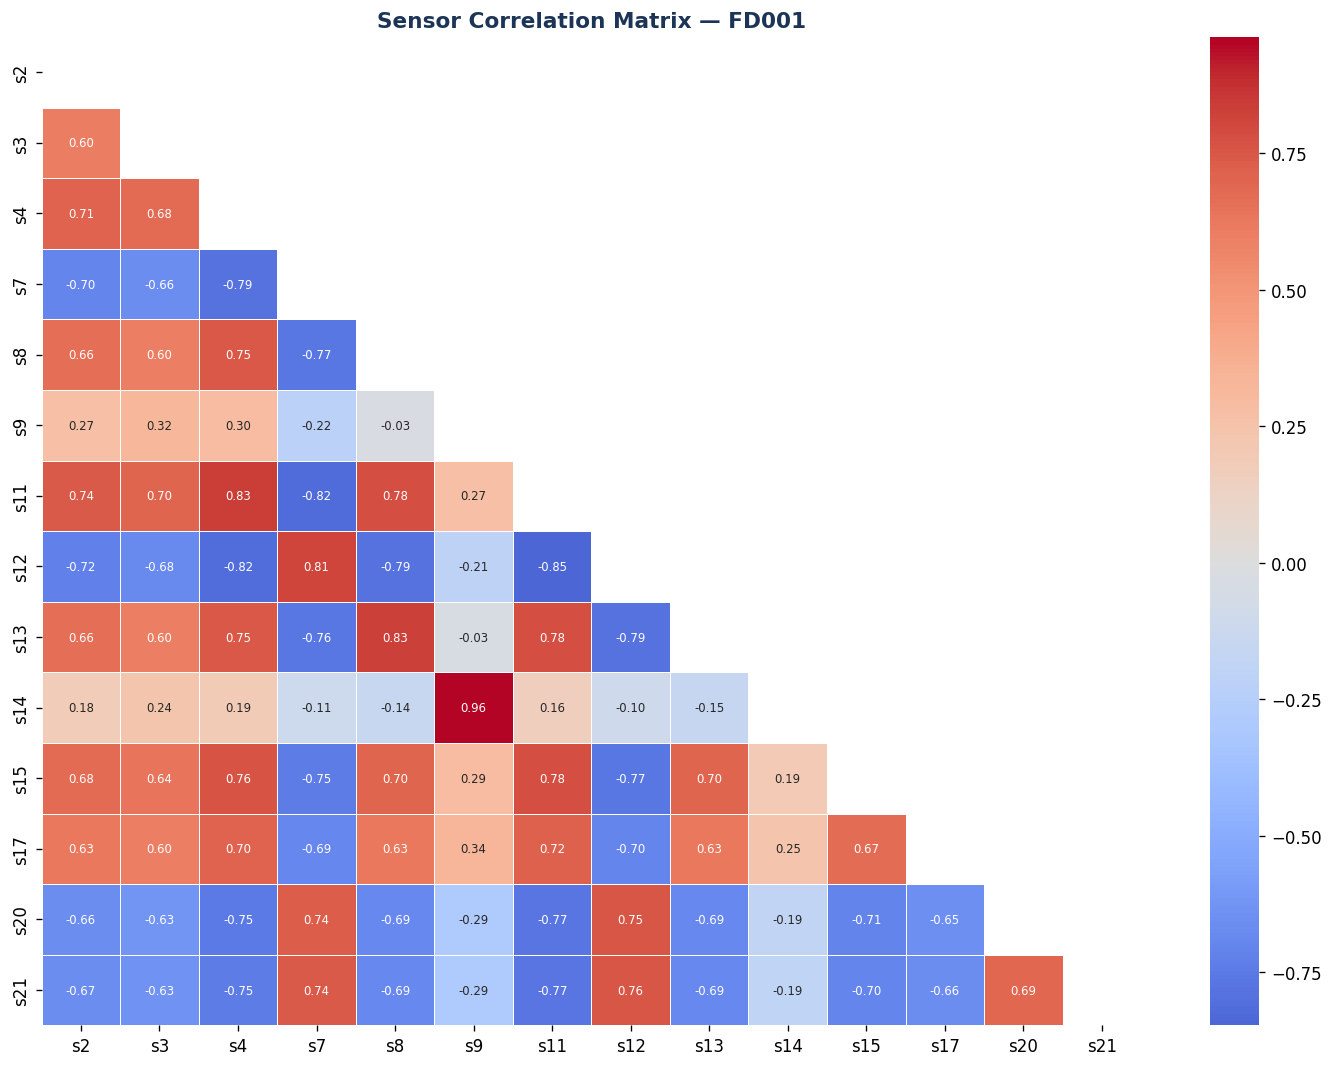

Saved: fig_correlation_matrix.png


In [8]:
# ── 2.4 Correlation Matrix (FD001) ─────────────────────────────────
corr_df = df_fd1[SENSORS].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            linewidths=0.5, cmap='coolwarm', center=0,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Sensor Correlation Matrix — FD001',
             fontsize=13, fontweight='bold', color=PALETTE['primary'])
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_correlation_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: fig_correlation_matrix.png')

---
## Phase 3: Preprocessing & Feature Engineering

**Feature set (42 features):**
- 14 raw sensors (dropped 7 low-variance + 3 op settings)
- 14 rolling mean features (window = 5 cycles per engine)
- 14 rolling std features (window = 5 cycles per engine)

In [9]:
def add_rul_column(df, threshold=RUL_THRESHOLD):
    """Compute piecewise linear capped RUL for every training row."""
    max_cycle = df.groupby('engine_id')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='engine_id')
    df['RUL'] = (df['max_cycle'] - df['cycle']).clip(upper=threshold)
    return df.drop(columns='max_cycle')


def add_rolling_features(df, sensors, window=WINDOW):
    """Rolling mean + rolling std per engine per sensor."""
    new_cols = {}
    for s in sensors:
        grp = df.groupby('engine_id')[s]
        new_cols[f'{s}_rmean'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        new_cols[f'{s}_rstd'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )
    return pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)


def remove_low_variance(df, sensors, threshold=0.02):
    """Drop sensors whose std < threshold — near constant."""
    kept    = [s for s in sensors if df[s].std() >= threshold]
    removed = set(sensors) - set(kept)
    if removed:
        print(f'  Dropped low-variance sensors: {sorted(removed)}')
    return kept


def preprocess(train_df, test_df, rul_df,
               drop_sensors=DROP_SENSORS,
               threshold=RUL_THRESHOLD):
    """Full preprocessing pipeline."""

    # 1. RUL label
    train_df = add_rul_column(train_df, threshold)

    # 2. Active sensors after dropping known-bad ones
    raw_sensors = [c for c in train_df.columns
                   if c.startswith('s') and c not in drop_sensors]
    sensors = remove_low_variance(train_df, raw_sensors)

    # 3. Rolling features (42 total)
    train_df = add_rolling_features(train_df, sensors)
    test_df  = add_rolling_features(test_df,  sensors)

    # 4. Feature column list
    roll_cols    = ([f'{s}_rmean' for s in sensors] +
                    [f'{s}_rstd'  for s in sensors])
    feature_cols = sensors + roll_cols

    # 5. Outlier clipping — IQR × 1.5 computed on train
    for col in feature_cols:
        q1, q3 = train_df[col].quantile([0.25, 0.75])
        iqr    = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        train_df[col] = train_df[col].clip(lo, hi)
        test_df[col]  = test_df[col].clip(lo, hi)

    # 6. StandardScaler — fit on train, transform both
    scaler = StandardScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

    # 7. Test targets — last cycle of each engine + true RUL
    test_last = test_df.groupby('engine_id').last().reset_index()
    test_last['RUL'] = rul_df['RUL_true'].values
    test_last['RUL'] = test_last['RUL'].clip(upper=threshold)

    return train_df, test_last, feature_cols, sensors, scaler


# ── Run preprocessing on all 4 subsets ────────────────────────────
processed = {}
for s in SUBSETS:
    print(f'\n── {s} ──')
    tr, te, rul = (datasets[s]['train'].copy(),
                   datasets[s]['test'].copy(),
                   datasets[s]['rul'])
    tr_p, te_p, feat_cols, sensors, scaler = preprocess(tr, te, rul)
    processed[s] = {
        'train'   : tr_p,
        'test'    : te_p,
        'features': feat_cols,
        'sensors' : sensors,
        'scaler'  : scaler,
    }
    print(f'  Train rows  : {len(tr_p):,}')
    print(f'  Feature cols: {len(feat_cols)}  '
          f'({len(sensors)} sensors + {len(sensors)} rmean + {len(sensors)} rstd)')

print('\nPreprocessing complete.')


── FD001 ──
  Train rows  : 20,631
  Feature cols: 42  (14 sensors + 14 rmean + 14 rstd)

── FD002 ──
  Train rows  : 53,759
  Feature cols: 42  (14 sensors + 14 rmean + 14 rstd)

── FD003 ──
  Train rows  : 24,720
  Feature cols: 42  (14 sensors + 14 rmean + 14 rstd)

── FD004 ──
  Train rows  : 61,249
  Feature cols: 42  (14 sensors + 14 rmean + 14 rstd)

Preprocessing complete.


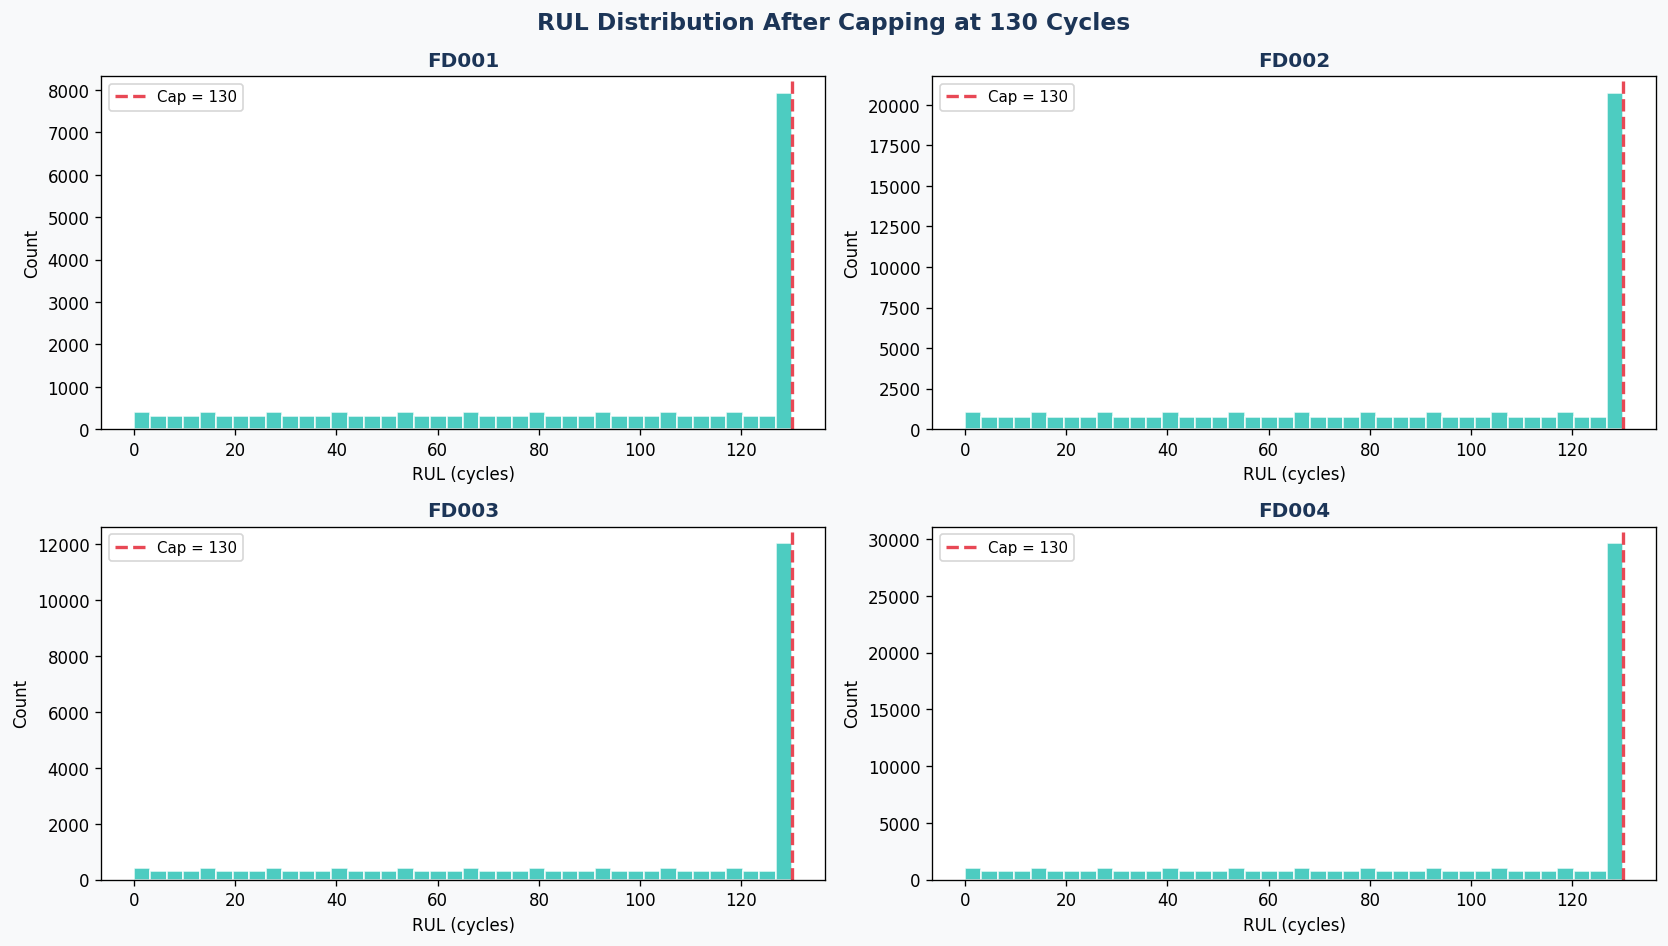

Saved: fig_rul_distribution.png


In [10]:
# ── RUL distribution after capping ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor=PALETTE['bg'])
fig.suptitle(f'RUL Distribution After Capping at {RUL_THRESHOLD} Cycles',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    rul_vals = processed[s]['train']['RUL']
    ax.hist(rul_vals, bins=40, color=PALETTE['green'],
            edgecolor='white', alpha=0.85)
    ax.axvline(RUL_THRESHOLD, color=PALETTE['accent'], lw=2,
               linestyle='--', label=f'Cap = {RUL_THRESHOLD}')
    ax.set_title(s, fontweight='bold', color=PALETTE['primary'])
    ax.set_xlabel('RUL (cycles)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_rul_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig_rul_distribution.png')

---
## Phase 4: Operating Condition-Aware Clustering (Novelty 2)
### 4A — Elbow Curve to Justify K=3

Computing elbow curves...


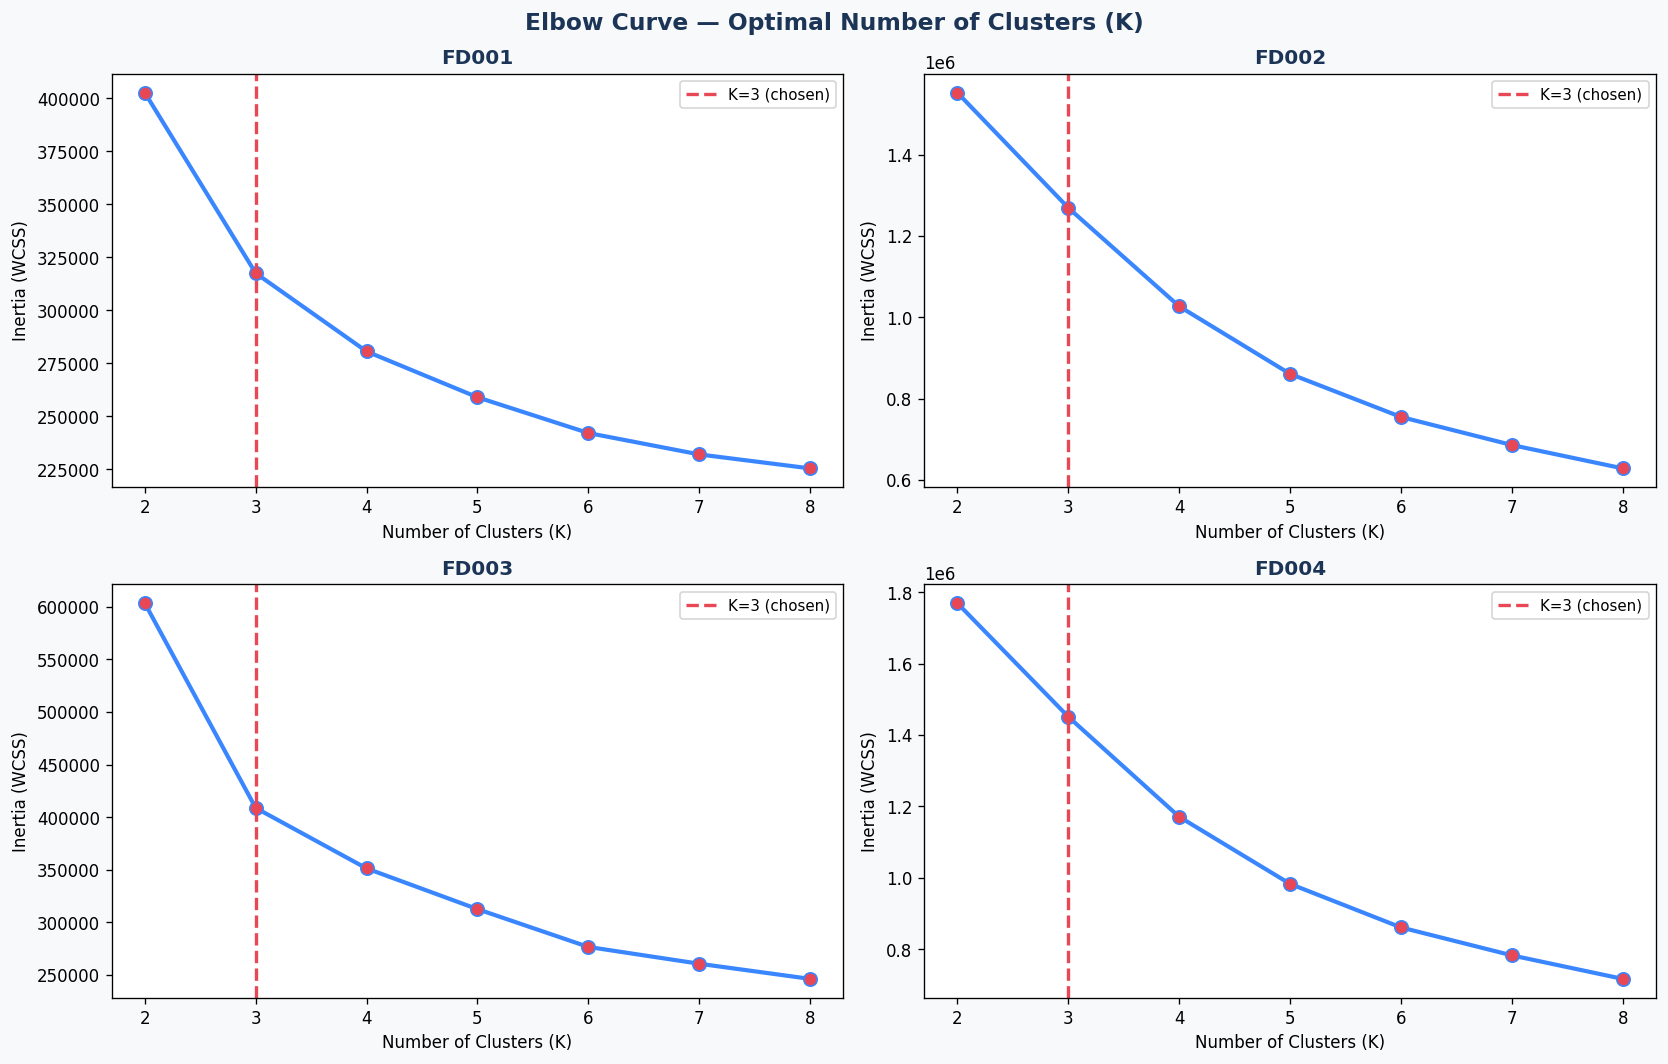

K=3 is the elbow point.


In [11]:
# ── Elbow curve — K=2 to K=8 for all subsets ──────────────────────
print('Computing elbow curves...')
K_RANGE = range(2, 9)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor=PALETTE['bg'])
fig.suptitle('Elbow Curve — Optimal Number of Clusters (K)',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    tr    = processed[s]['train']
    feat  = processed[s]['features']
    X     = tr[feat].values
    pca_e = PCA(n_components=N_PCA, random_state=42)
    X_pca = pca_e.fit_transform(X)

    inertias = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_pca)
        inertias.append(km.inertia_)

    ax.plot(list(K_RANGE), inertias, 'o-',
            color=PALETTE['mid'], lw=2.5, ms=8,
            markerfacecolor=PALETTE['accent'])
    ax.axvline(N_CLUSTERS, color=PALETTE['accent'], lw=2,
               linestyle='--', label=f'K={N_CLUSTERS} (chosen)')
    ax.set_title(s, fontweight='bold', color=PALETTE['primary'])
    ax.set_xlabel('Number of Clusters (K)')
    ax.set_ylabel('Inertia (WCSS)')
    ax.legend(fontsize=9)
    ax.set_facecolor('white')
    ax.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_elbow_curve.png', bbox_inches='tight')
plt.show()
print('K=3 is the elbow point.')

In [12]:
# ── Fit PCA + KMeans (K=3) on all subsets ─────────────────────────
def fit_cluster_pipeline(train_df, feature_cols,
                          n_components=N_PCA,
                          n_clusters=N_CLUSTERS):
    X      = train_df[feature_cols].values
    pca    = PCA(n_components=n_components, random_state=42)
    X_pca  = pca.fit_transform(X)
    km     = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    return pca, km, labels


def assign_clusters(df, pca, km, feature_cols):
    X_pca = pca.transform(df[feature_cols].values)
    return km.predict(X_pca)


cluster_pipes = {}
for s in SUBSETS:
    tr   = processed[s]['train']
    feat = processed[s]['features']
    pca, km, labels = fit_cluster_pipeline(tr, feat)
    processed[s]['train'] = tr.copy()
    processed[s]['train']['cluster'] = labels
    processed[s]['test']['cluster']  = assign_clusters(
        processed[s]['test'], pca, km, feat
    )
    cluster_pipes[s] = {'pca': pca, 'km': km}
    counts = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f'{s} cluster sizes: {counts}')

print('\nClustering complete.')

FD001 cluster sizes: {0: 9083, 1: 7467, 2: 4081}
FD002 cluster sizes: {0: 20503, 1: 15632, 2: 17624}
FD003 cluster sizes: {0: 14265, 1: 6950, 2: 3505}
FD004 cluster sizes: {0: 18029, 1: 23459, 2: 19761}

Clustering complete.


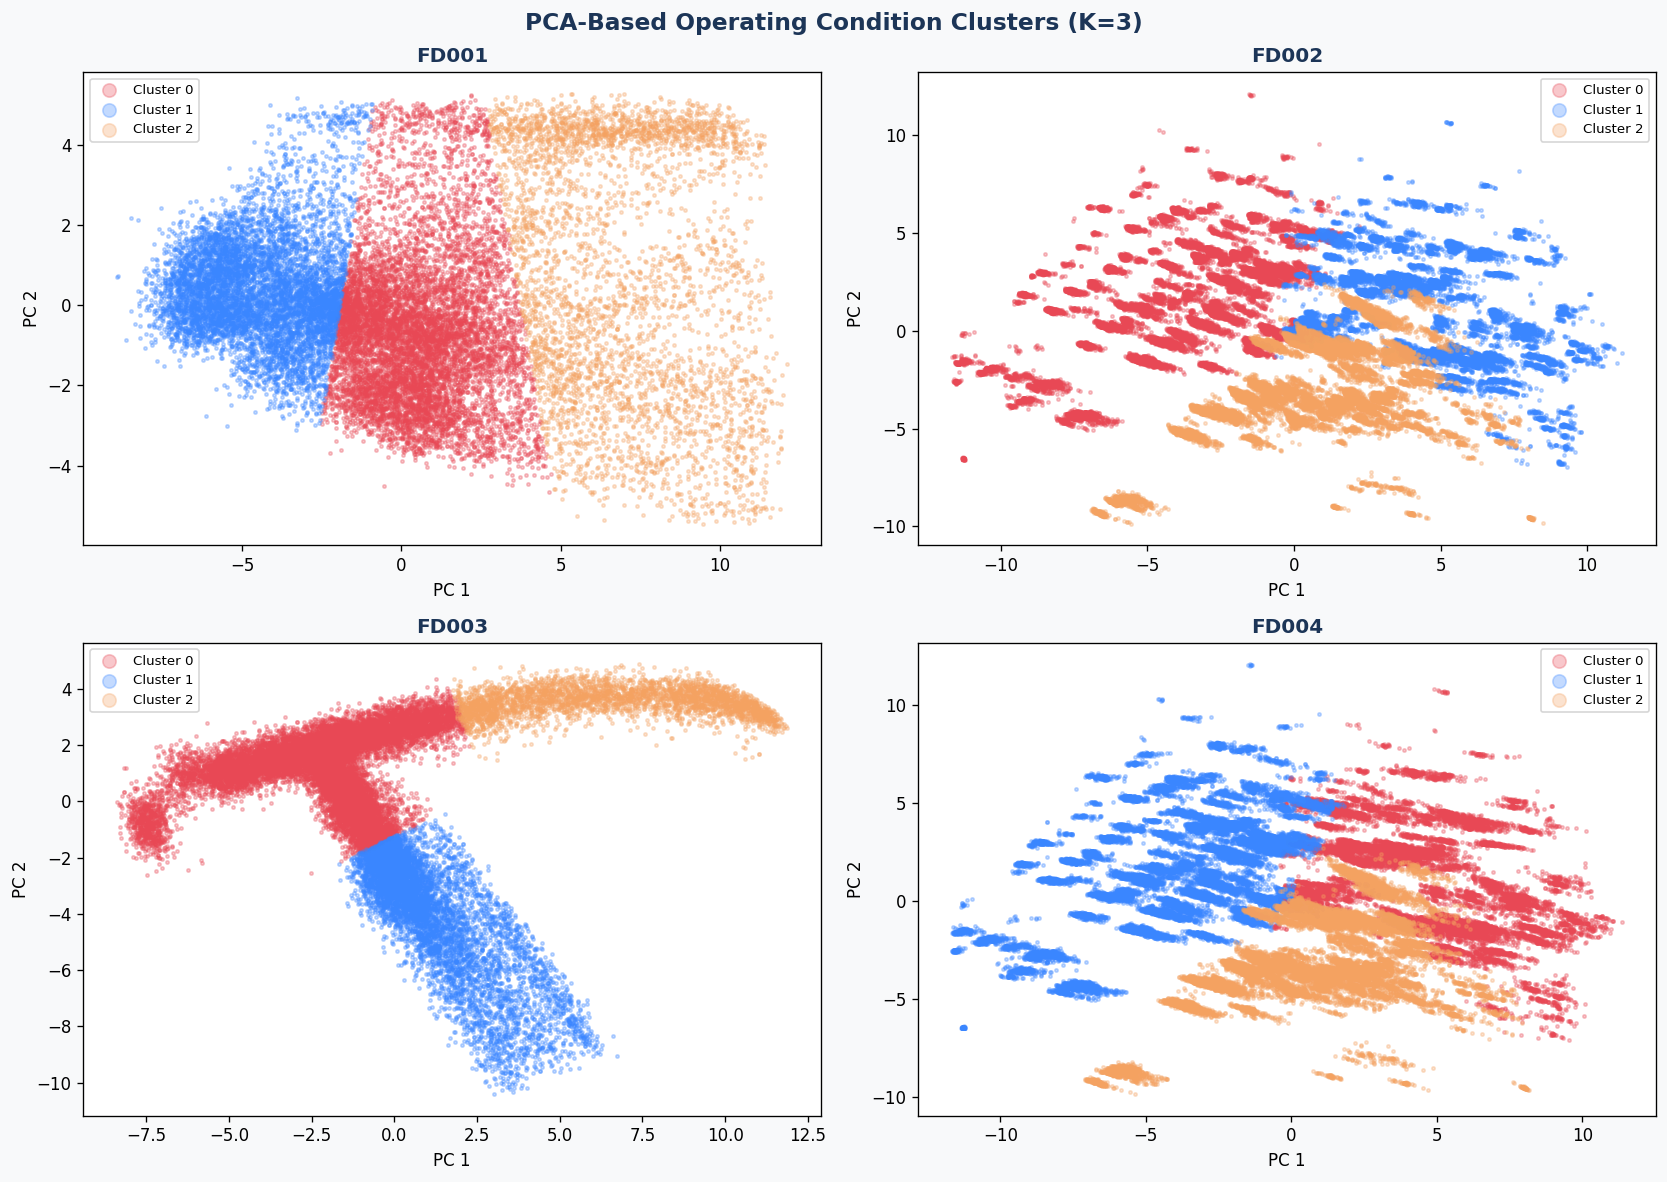

Saved: fig_pca_clusters.png


In [13]:
# ── PCA 2D cluster scatter ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=PALETTE['bg'])
fig.suptitle('PCA-Based Operating Condition Clusters (K=3)',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])
clr = [PALETTE['accent'], PALETTE['mid'], PALETTE['gold']]

for ax, s in zip(axes.flatten(), SUBSETS):
    tr   = processed[s]['train']
    feat = processed[s]['features']
    pca  = cluster_pipes[s]['pca']
    X2   = pca.transform(tr[feat].values)[:, :2]
    for c in range(N_CLUSTERS):
        idx = tr['cluster'].values == c
        ax.scatter(X2[idx, 0], X2[idx, 1],
                   c=clr[c], alpha=0.3, s=4,
                   label=f'Cluster {c}')
    ax.set_title(s, fontweight='bold', color=PALETTE['primary'])
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.legend(fontsize=8, markerscale=4)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_pca_clusters.png', bbox_inches='tight')
plt.show()
print('Saved: fig_pca_clusters.png')

---
## Phase 5: Model Training — Cluster-Specific Adaptive Ensemble (Novelty 1)

**Key design decisions:**
- **Softmax temperature weighting (T=3.0)** replaces inverse-RMSE → better weight divergence
- **BIAS_ALPHA = 0.35** → 35% life-stage + 65% validation weight
- **Strongly divergent life-stage weights** → early trusts trees, late trusts boosting
- **Validation split = 30%** for calibration residuals

In [14]:
# ── Base model factory ─────────────────────────────────────────────
def get_base_models():
    return {
        'XGBoost'    : XGBRegressor(
                           n_estimators=300, max_depth=6,
                           learning_rate=0.05, subsample=0.8,
                           colsample_bytree=0.8,
                           random_state=42, verbosity=0),

        'LightGBM'   : lgb.LGBMRegressor(
                           n_estimators=300, max_depth=6,
                           learning_rate=0.05, subsample=0.8,
                           num_leaves=50, 
                           random_state=42, verbose=-1),

        'ExtraTrees' : ExtraTreesRegressor(
                           n_estimators=200, max_depth=None,
                           min_samples_split=4, min_samples_leaf=2,
                           random_state=42, n_jobs=-1),

        'MLP'        : MLPRegressor(
                           hidden_layer_sizes=(128, 64, 32),
                           activation='relu', max_iter=300,
                           learning_rate_init=0.001,
                           random_state=42),

        'RandomForest': RandomForestRegressor(
                           n_estimators=200, max_depth=None,
                           min_samples_split=4, min_samples_leaf=2,
                           random_state=42, n_jobs=-1),
    }

MODEL_NAMES = list(get_base_models().keys())


# ── Softmax temperature weighting (FIX for uniform weights) ───────
def compute_val_weights(val_rmse, temperature=3.0):
    """
    Softmax-based weighting with temperature scaling.
    Better than inverse-RMSE because it amplifies small RMSE
    differences exponentially, giving meaningful weight spread.

    temperature=3.0:
      - Lower = more winner-takes-all
      - Higher = more uniform
      - 3.0 gives good spread without being too extreme
    """
    names  = list(val_rmse.keys())
    rmses  = np.array([val_rmse[m] for m in names])
    # Negative because lower RMSE = better = higher weight
    scores = -rmses / temperature
    scores = scores - scores.max()      # numerical stability
    exp_s  = np.exp(scores)
    weights = exp_s / exp_s.sum()
    return {names[i]: float(weights[i]) for i in range(len(names))}


# ── Life-stage bias weights (strongly divergent) ──────────────────
# Order: XGBoost, LightGBM, ExtraTrees, MLP, RandomForest
LIFE_STAGE_BIAS = {
    'early': np.array([0.10, 0.10, 0.40, 0.10, 0.30]),  # trees dominate
    'mid'  : np.array([0.25, 0.25, 0.20, 0.15, 0.15]),  # balanced
    'late' : np.array([0.45, 0.35, 0.08, 0.07, 0.05]),  # boosting dominates
}


def get_life_stage(rul_val):
    if rul_val > 100:
        return 'early'
    elif rul_val <= 30:
        return 'late'
    else:
        return 'mid'


def compute_adaptive_weight(val_weights, life_stage,
                             alpha=BIAS_ALPHA):
    """
    Blend validation weights with life-stage bias.
    alpha=0.35: 35% life-stage + 65% validation data evidence.
    """
    w_val   = np.array([val_weights[m] for m in MODEL_NAMES])
    w_bias  = LIFE_STAGE_BIAS[life_stage]
    blended = (1 - alpha) * w_val + alpha * w_bias
    return blended / blended.sum()


def train_ensemble(train_df, feature_cols, val_size=0.30):
    """
    Train all 5 base models on a cluster's data.
    Returns: models, val_weights (softmax), val_rmse,
             calibration residuals for conformal prediction.
    """
    X = train_df[feature_cols].values
    y = train_df['RUL'].values

    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=val_size, random_state=42
    )

    models   = get_base_models()
    val_rmse = {}
    for name, mdl in models.items():
        mdl.fit(X_tr, y_tr)
        p = mdl.predict(X_val)
        val_rmse[name] = np.sqrt(mean_squared_error(y_val, p))

    # Softmax temperature weighting (key fix)
    val_weights = compute_val_weights(val_rmse, temperature=3.0)

    # Calibration residuals for conformal prediction
    all_preds = np.column_stack([models[m].predict(X_val) for m in MODEL_NAMES])  # shape: (n_val, 5)

    # Compute life stage for each sample using mean prediction
    avg_preds = all_preds.mean(axis=1)

    # Assign weights per sample based on life stage
    weight_matrix = np.zeros((len(y_val), len(MODEL_NAMES)))
    for i, avg_p in enumerate(avg_preds): 
        stage = get_life_stage(avg_p)
        weight_matrix[i] = compute_adaptive_weight(val_weights, stage)

    # Ensemble prediction for each sample
    ens_preds = (weight_matrix * all_preds).sum(axis=1)

    # Calibration residuals
    cal_residuals = np.abs(y_val - ens_preds)

    return models, val_weights, val_rmse, cal_residuals


# ── Train all clusters ─────────────────────────────────────────────
print('Training cluster-specific ensembles for all subsets...')

ensemble_store = {}
for s in SUBSETS:
    ensemble_store[s] = {}
    tr   = processed[s]['train']
    feat = processed[s]['features']
    print(f'  ── {s} ──')
    for c in range(N_CLUSTERS):
        tr_c = tr[tr['cluster'] == c]
        if len(tr_c) < 50:
            print(f'    Cluster {c}: too few samples, skipping.')
            continue
        models, val_weights, val_rmse, cal_res = train_ensemble(tr_c, feat)
        ensemble_store[s][c] = {
            'models'        : models,
            'val_weights'   : val_weights,
            'val_rmse'      : val_rmse,
            'cal_residuals' : cal_res,
        }
        best_m = min(val_rmse, key=val_rmse.get)
        w_str  = ', '.join(
            [f'{m[:3]}={val_weights[m]:.2f}' for m in MODEL_NAMES]
        )
        print(f'    Cluster {c} ({len(tr_c):5,} rows) — '
              f'Best: {best_m} (RMSE {val_rmse[best_m]:.2f}) | '
              f'Weights: {w_str}')

print('\n All cluster-specific ensembles trained.')

Training cluster-specific ensembles for all subsets...
  ── FD001 ──
    Cluster 0 (9,083 rows) — Best: ExtraTrees (RMSE 21.00) | Weights: XGB=0.23, Lig=0.24, Ext=0.28, MLP=0.02, Ran=0.23
    Cluster 1 (7,467 rows) — Best: ExtraTrees (RMSE 12.63) | Weights: XGB=0.23, Lig=0.23, Ext=0.25, MLP=0.07, Ran=0.22
    Cluster 2 (4,081 rows) — Best: LightGBM (RMSE 7.08) | Weights: XGB=0.23, Lig=0.24, Ext=0.22, MLP=0.11, Ran=0.20
  ── FD002 ──
    Cluster 0 (20,503 rows) — Best: MLP (RMSE 20.63) | Weights: XGB=0.19, Lig=0.18, Ext=0.20, MLP=0.28, Ran=0.15
    Cluster 1 (15,632 rows) — Best: MLP (RMSE 19.08) | Weights: XGB=0.20, Lig=0.19, Ext=0.20, MLP=0.23, Ran=0.18
    Cluster 2 (17,624 rows) — Best: MLP (RMSE 19.89) | Weights: XGB=0.20, Lig=0.19, Ext=0.20, MLP=0.25, Ran=0.16
  ── FD003 ──
    Cluster 0 (14,265 rows) — Best: ExtraTrees (RMSE 13.21) | Weights: XGB=0.23, Lig=0.22, Ext=0.25, MLP=0.08, Ran=0.22
    Cluster 1 (6,950 rows) — Best: ExtraTrees (RMSE 16.21) | Weights: XGB=0.22, Lig=0.22, 

---
## Phase 6: Prediction - Adaptive Ensemble + Calibrated Uncertainty (Novelty 1 & 3)

**conformal_quantile = 0.85** — 85th percentile for tighter, more precise intervals

In [15]:
def predict_adaptive_ensemble(test_df, ensemble_store_s,
                               feature_cols,
                               conformal_quantile=0.85):
    """
    Route each test sample to its cluster ensemble.
    Returns adaptive, simple-avg, best-single predictions
    and calibrated uncertainty intervals.
    """
    n = len(test_df)
    adaptive_pred    = np.zeros(n)
    simple_avg_pred  = np.zeros(n)
    best_single_pred = np.zeros(n)
    pred_std         = np.zeros(n)

    X_test   = test_df[feature_cols].values
    clusters = test_df['cluster'].values

    # Best single model across all clusters
    avg_val_rmse = {m: [] for m in MODEL_NAMES}
    for c_ens in ensemble_store_s.values():
        for m, r in c_ens['val_rmse'].items():
            avg_val_rmse[m].append(r)
    best_model_name = min(
        avg_val_rmse,
        key=lambda m: np.mean(avg_val_rmse[m])
    )

    # Conformal quantile — 85th percentile of all val residuals
    all_cal_res = np.concatenate(
        [v['cal_residuals'] for v in ensemble_store_s.values()]
    )
    Q = float(np.quantile(all_cal_res, conformal_quantile))

    for i, (xi, ci) in enumerate(zip(X_test, clusters)):
        xi = xi.reshape(1, -1)
        if ci not in ensemble_store_s:
            ci = list(ensemble_store_s.keys())[0]

        ens    = ensemble_store_s[ci]
        models = ens['models']
        vw     = ens['val_weights']

        preds = {m: float(models[m].predict(xi)) for m in models}
        p_arr = np.array([preds[m] for m in MODEL_NAMES])
        avg_p = float(np.mean(p_arr))

        stage   = get_life_stage(avg_p)
        blended = compute_adaptive_weight(vw, stage)
        final   = float(np.dot(blended, p_arr))

        adaptive_pred[i]    = final
        simple_avg_pred[i]  = avg_p
        best_single_pred[i] = preds.get(best_model_name, avg_p)
        pred_std[i]         = float(np.std(p_arr))

    pred_lower = adaptive_pred - Q
    pred_upper = adaptive_pred + Q

    return {
        'adaptive'       : adaptive_pred,
        'simple_avg'     : simple_avg_pred,
        'best_single'    : best_single_pred,
        'lower'          : pred_lower,
        'upper'          : pred_upper,
        'std'            : pred_std,
        'best_model_name': best_model_name,
        'conformal_Q'    : Q,
    }


# ── Generate predictions for all subsets ──────────────────────────
print('Generating calibrated predictions...\n')

results = {}
for s in SUBSETS:
    te    = processed[s]['test']
    feat  = processed[s]['features']
    preds = predict_adaptive_ensemble(
        te, ensemble_store[s], feat,
        conformal_quantile=0.85   # FIX: tighter intervals
    )
    y_true = te['RUL'].values

    def metrics(y, p):
        return (np.sqrt(mean_squared_error(y, p)),
                r2_score(y, p))

    rmse_adp, r2_adp = metrics(y_true, preds['adaptive'])
    rmse_avg, r2_avg = metrics(y_true, preds['simple_avg'])
    rmse_sgl, r2_sgl = metrics(y_true, preds['best_single'])

    in_pi = ((y_true >= preds['lower']) &
             (y_true <= preds['upper']))
    picp = in_pi.mean() * 100
    mpiw = np.mean(preds['upper'] - preds['lower'])

    gain_vs_avg = rmse_avg - rmse_adp
    gain_vs_sgl = rmse_sgl - rmse_adp

    results[s] = {
        'y_true' : y_true,
        'preds'  : preds,
        'metrics': {
            'Adaptive Ensemble'                          : (rmse_adp, r2_adp),
            'Simple Average'                             : (rmse_avg, r2_avg),
            f'Best Single ({preds["best_model_name"]})' : (rmse_sgl, r2_sgl),
        },
        'picp'       : picp,
        'mpiw'       : mpiw,
        'conformal_Q': preds['conformal_Q'],
    }

    print(f'{s}:')
    print(f'  Adaptive Ensemble  → RMSE: {rmse_adp:.3f}, R²: {r2_adp:.3f}')
    print(f'  Simple Average     → RMSE: {rmse_avg:.3f}, R²: {r2_avg:.3f}'
          f'  [Adaptive gain: {gain_vs_avg:+.3f}]')
    print(f'  Best Single ({preds["best_model_name"]:12s})'
          f' → RMSE: {rmse_sgl:.3f}, R²: {r2_sgl:.3f}'
          f'  [Adaptive gain: {gain_vs_sgl:+.3f}]')
    print(f'  PICP (80% PI)      → {picp:.1f}%  |  '
          f'MPIW: {mpiw:.2f}  |  Q: {preds["conformal_Q"]:.2f}\n')

print('Predictions complete.')

Generating calibrated predictions...

FD001:
  Adaptive Ensemble  → RMSE: 18.036, R²: 0.803
  Simple Average     → RMSE: 17.930, R²: 0.806  [Adaptive gain: -0.107]
  Best Single (ExtraTrees  ) → RMSE: 18.612, R²: 0.791  [Adaptive gain: +0.576]
  PICP (80% PI)      → 77.0%  |  MPIW: 43.16  |  Q: 21.58

FD002:
  Adaptive Ensemble  → RMSE: 17.640, R²: 0.841
  Simple Average     → RMSE: 17.664, R²: 0.841  [Adaptive gain: +0.024]
  Best Single (MLP         ) → RMSE: 17.467, R²: 0.844  [Adaptive gain: -0.173]
  PICP (80% PI)      → 90.7%  |  MPIW: 58.10  |  Q: 29.05

FD003:
  Adaptive Ensemble  → RMSE: 20.489, R²: 0.738
  Simple Average     → RMSE: 20.674, R²: 0.734  [Adaptive gain: +0.185]
  Best Single (ExtraTrees  ) → RMSE: 20.342, R²: 0.742  [Adaptive gain: -0.148]
  PICP (80% PI)      → 73.0%  |  MPIW: 37.80  |  Q: 18.90

FD004:
  Adaptive Ensemble  → RMSE: 21.333, R²: 0.769
  Simple Average     → RMSE: 21.348, R²: 0.769  [Adaptive gain: +0.015]
  Best Single (MLP         ) → RMSE: 21.4

---
## Phase 7: Visualizations

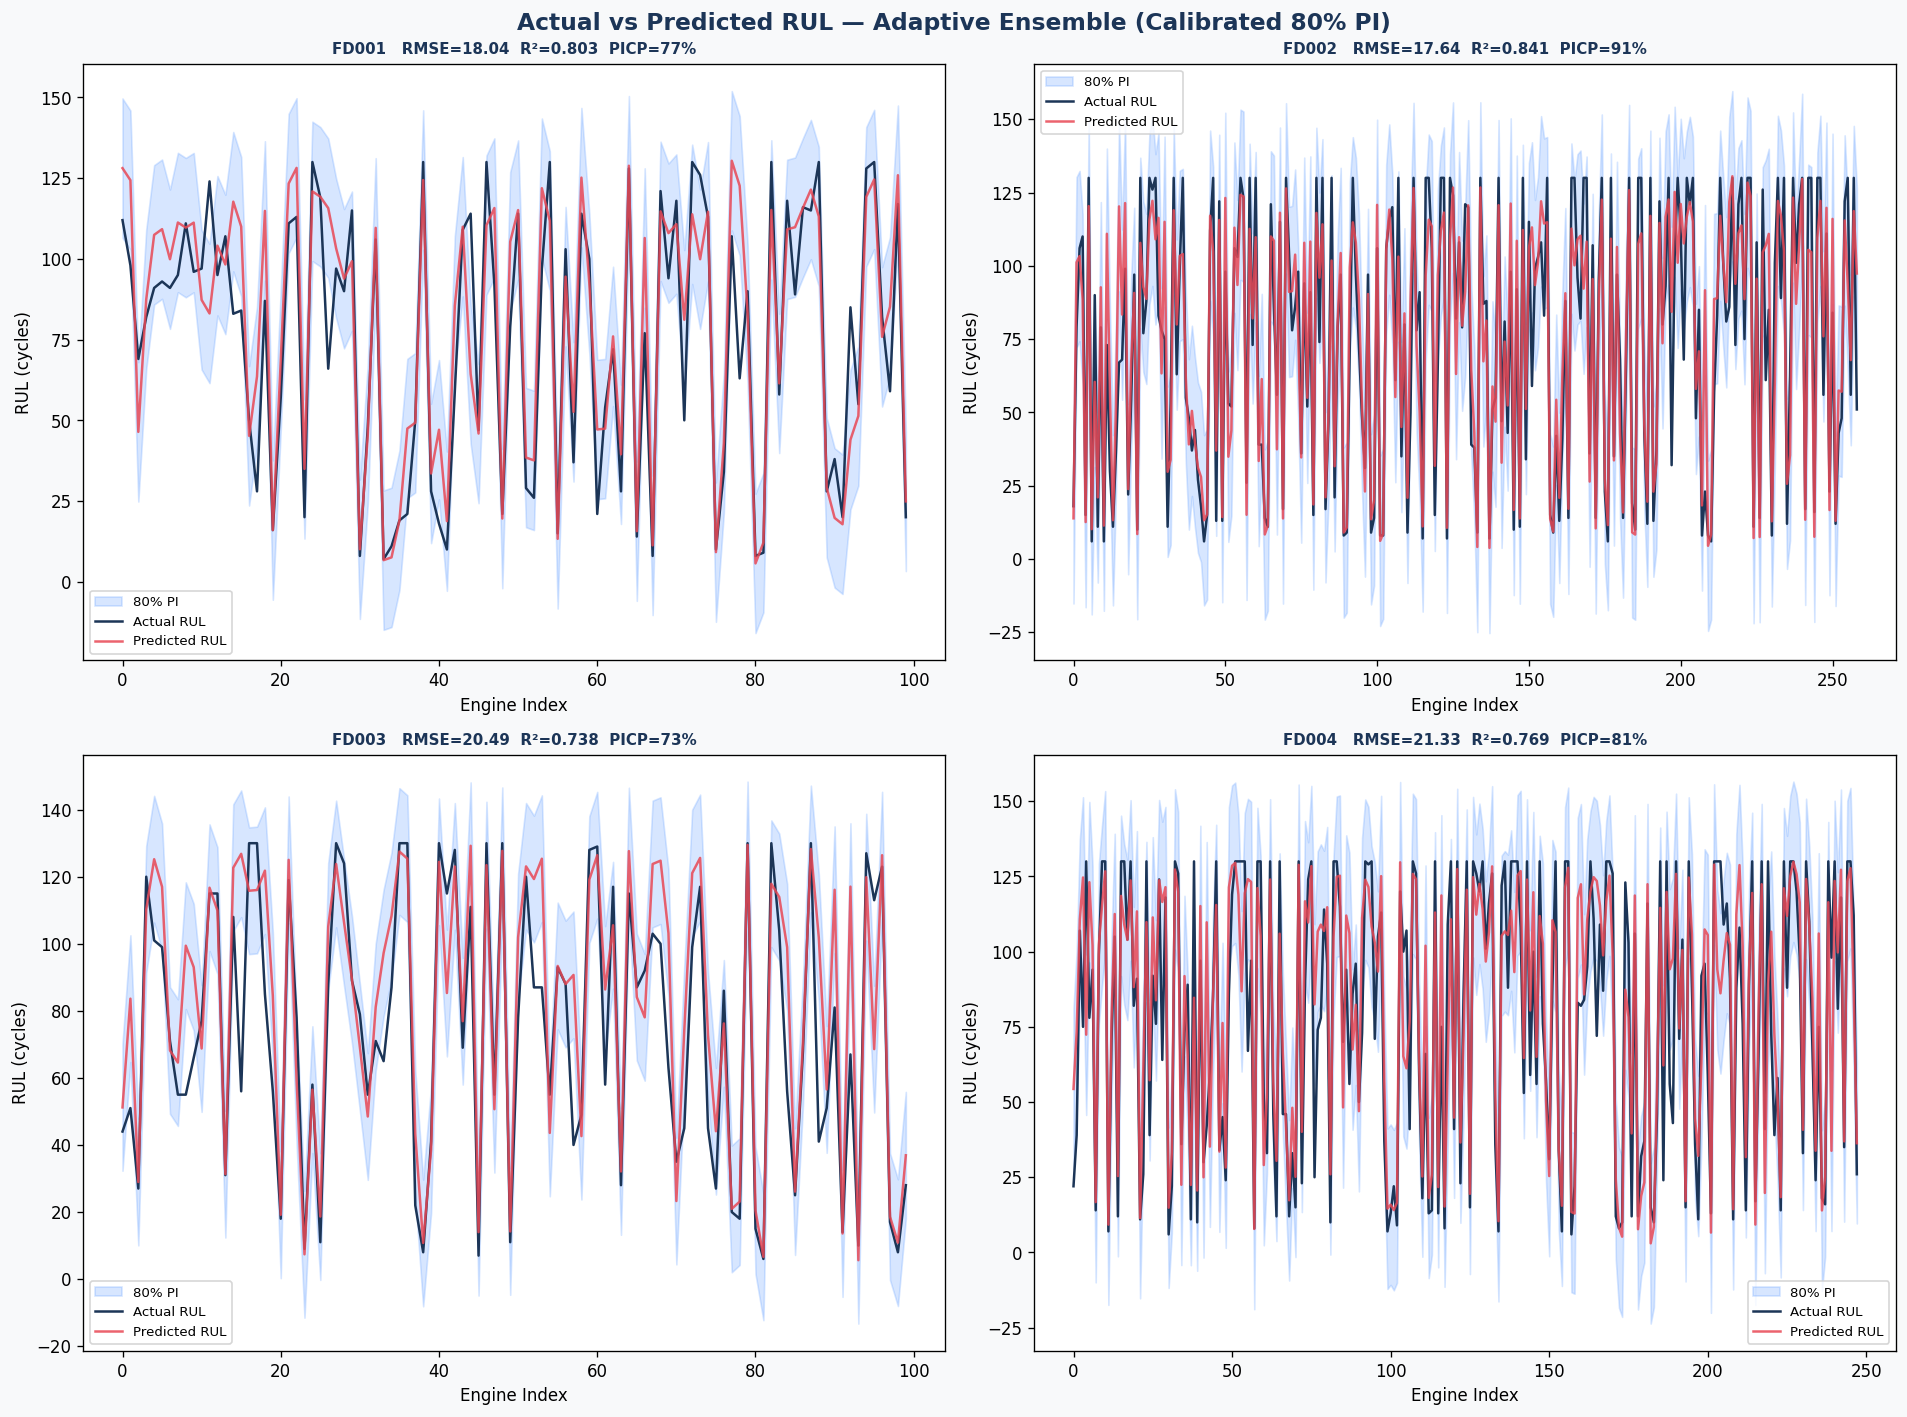

Saved: fig_actual_vs_predicted.png


In [16]:
# ── 7.1 Actual vs Predicted — all subsets with PI bands ───────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=PALETTE['bg'])
fig.suptitle('Actual vs Predicted RUL — Adaptive Ensemble (Calibrated 80% PI)',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    r      = results[s]
    y_true = r['y_true']
    y_pred = r['preds']['adaptive']
    lower  = r['preds']['lower']
    upper  = r['preds']['upper']
    idx    = np.arange(len(y_true))

    ax.fill_between(idx, lower, upper,
                    alpha=0.20, color=PALETTE['mid'], label='80% PI')
    ax.plot(idx, y_true, color=PALETTE['primary'],
            lw=1.5, label='Actual RUL', zorder=3)
    ax.plot(idx, y_pred, color=PALETTE['accent'],
            lw=1.5, alpha=0.85, label='Predicted RUL', zorder=4)

    rmse, r2 = r['metrics']['Adaptive Ensemble']
    ax.set_title(
        f'{s}   RMSE={rmse:.2f}  R²={r2:.3f}  PICP={r["picp"]:.0f}%',
        fontweight='bold', color=PALETTE['primary'], fontsize=9
    )
    ax.set_xlabel('Engine Index')
    ax.set_ylabel('RUL (cycles)')
    ax.legend(fontsize=8)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print('Saved: fig_actual_vs_predicted.png')

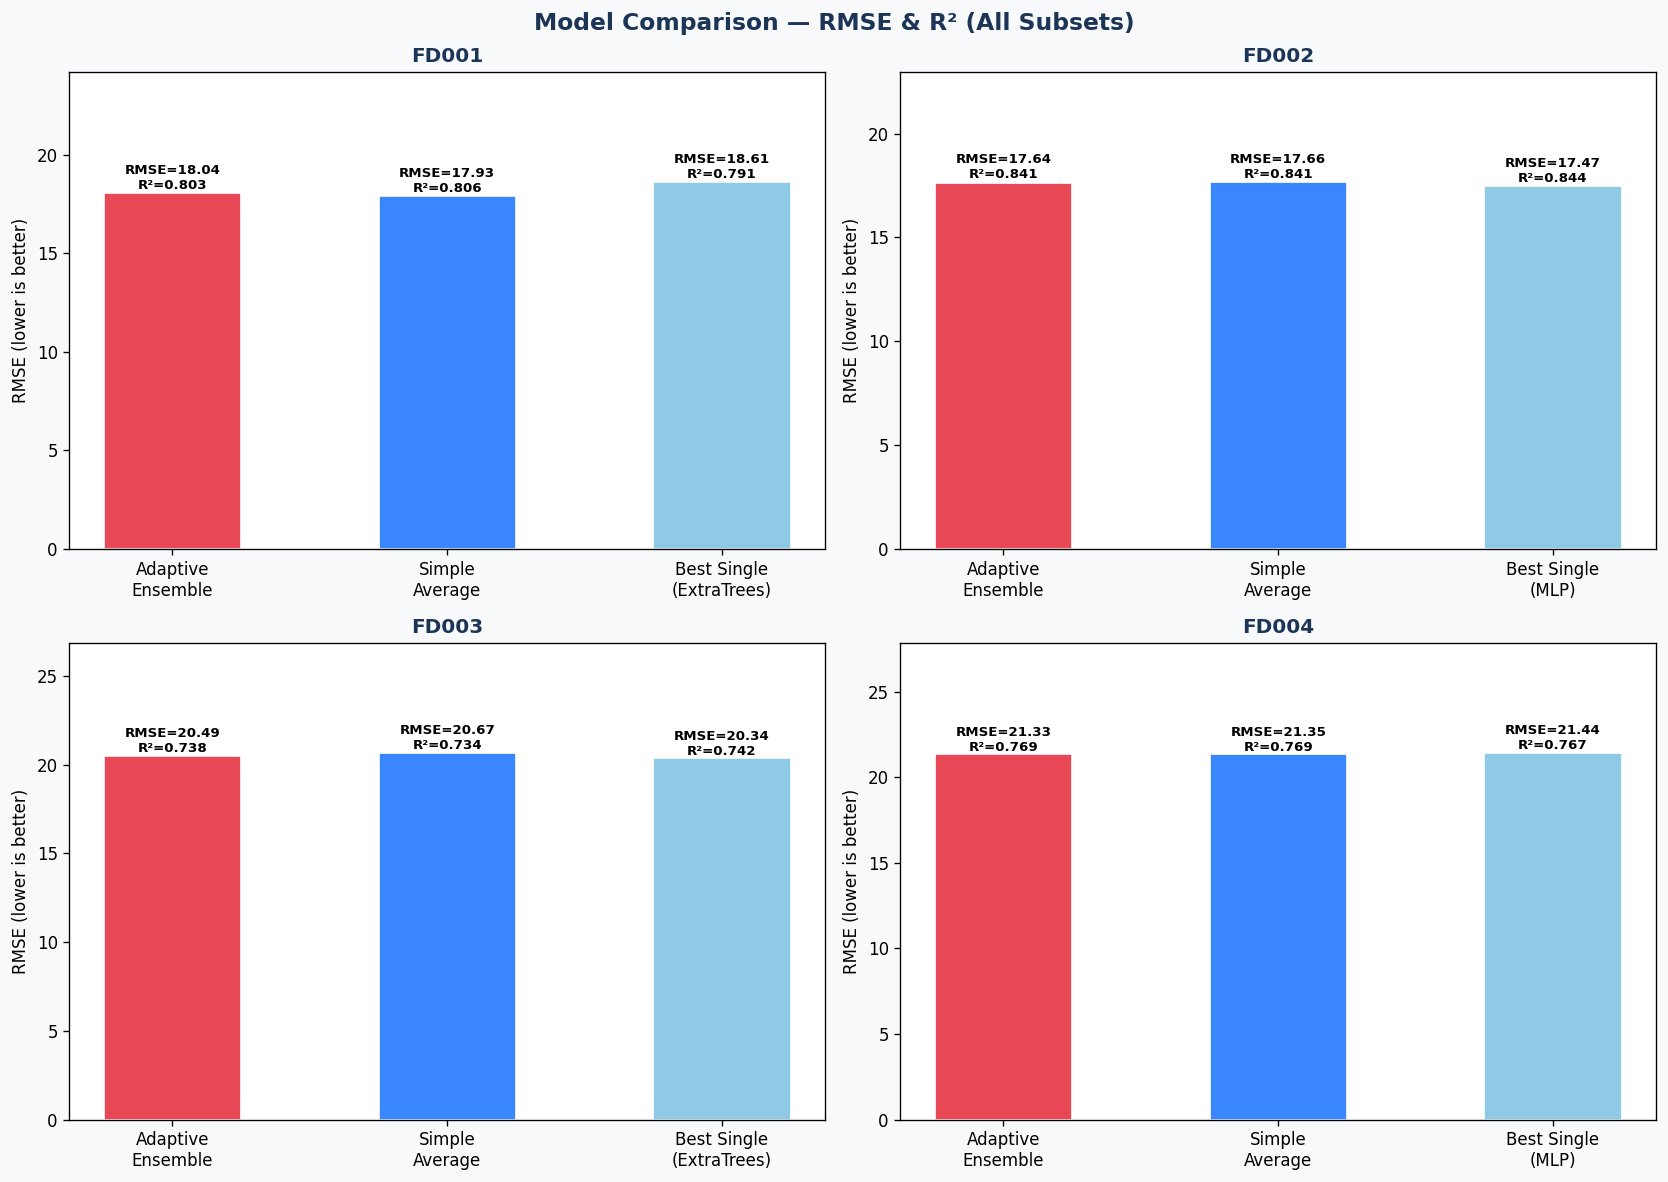

Saved: fig_rmse_comparison_all.png


In [17]:
# ── 7.2 Three-way RMSE + R² comparison — all subsets ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=PALETTE['bg'])
fig.suptitle('Model Comparison — RMSE & R² (All Subsets)',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])
bar_colors = [PALETTE['accent'], PALETTE['mid'], PALETTE['light']]

for ax, s in zip(axes.flatten(), SUBSETS):
    m_dict = results[s]['metrics']
    labels = ['Adaptive\nEnsemble', 'Simple\nAverage',
              f'Best Single\n({results[s]["preds"]["best_model_name"]})']
    rmses  = [v[0] for v in m_dict.values()]
    r2s    = [v[1] for v in m_dict.values()]

    bars = ax.bar(labels, rmses, color=bar_colors,
                  edgecolor='white', width=0.5)
    for bar, val, r2v in zip(bars, rmses, r2s):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'RMSE={val:.2f}\nR²={r2v:.3f}',
                ha='center', fontsize=8, fontweight='bold')

    ax.set_title(s, fontweight='bold', color=PALETTE['primary'])
    ax.set_ylabel('RMSE (lower is better)')
    ax.set_facecolor('white')
    ax.set_ylim(0, max(rmses) * 1.30)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_rmse_comparison_all.png', bbox_inches='tight')
plt.show()
print('Saved: fig_rmse_comparison_all.png')

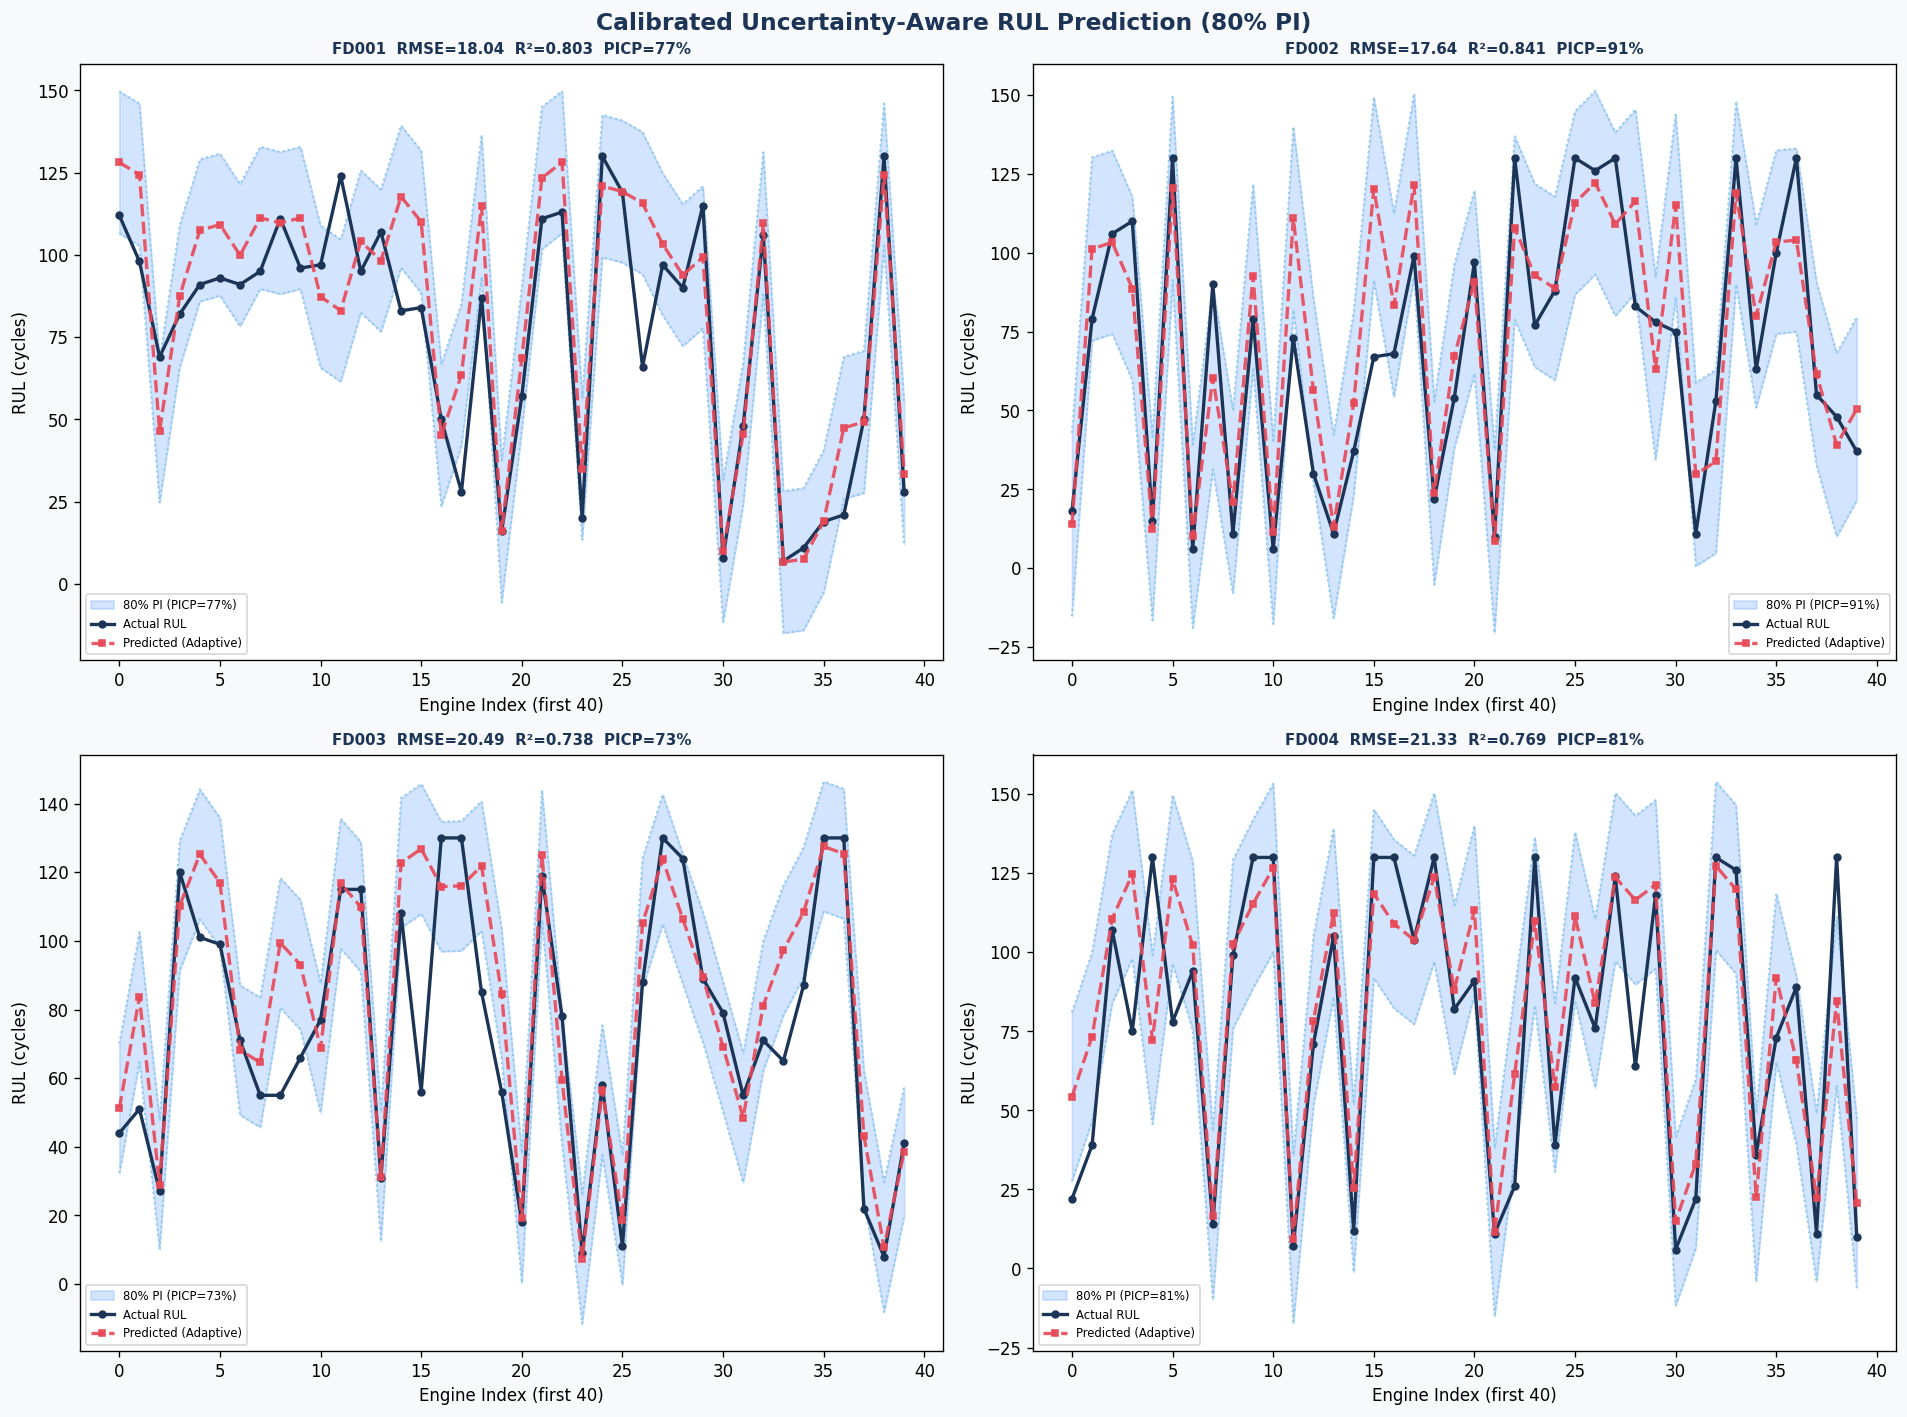

Saved: fig_uncertainty_prediction.png


In [18]:
# ── 7.3 Uncertainty detail — all 4 subsets ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=PALETTE['bg'])
fig.suptitle('Calibrated Uncertainty-Aware RUL Prediction (80% PI)',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    r      = results[s]
    n_show = min(40, len(r['y_true']))
    y_true = r['y_true'][:n_show]
    y_pred = r['preds']['adaptive'][:n_show]
    lower  = r['preds']['lower'][:n_show]
    upper  = r['preds']['upper'][:n_show]
    idx    = np.arange(n_show)

    ax.fill_between(idx, lower, upper,
                    alpha=0.22, color=PALETTE['mid'],
                    label=f'80% PI (PICP={r["picp"]:.0f}%)')
    ax.plot(idx, y_true, 'o-', color=PALETTE['primary'],
            lw=2, ms=4, label='Actual RUL', zorder=4)
    ax.plot(idx, y_pred, 's--', color=PALETTE['accent'],
            lw=2, ms=4, alpha=0.9,
            label='Predicted (Adaptive)', zorder=5)
    ax.plot(idx, lower, ':', color=PALETTE['light'], lw=1.2)
    ax.plot(idx, upper, ':', color=PALETTE['light'], lw=1.2)

    rmse, r2 = r['metrics']['Adaptive Ensemble']
    ax.set_title(
        f'{s}  RMSE={rmse:.2f}  R²={r2:.3f}  PICP={r["picp"]:.0f}%',
        fontweight='bold', color=PALETTE['primary'], fontsize=9
    )
    ax.set_xlabel(f'Engine Index (first {n_show})')
    ax.set_ylabel('RUL (cycles)')
    ax.legend(fontsize=7)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_uncertainty_prediction.png', bbox_inches='tight')
plt.show()
print('Saved: fig_uncertainty_prediction.png')

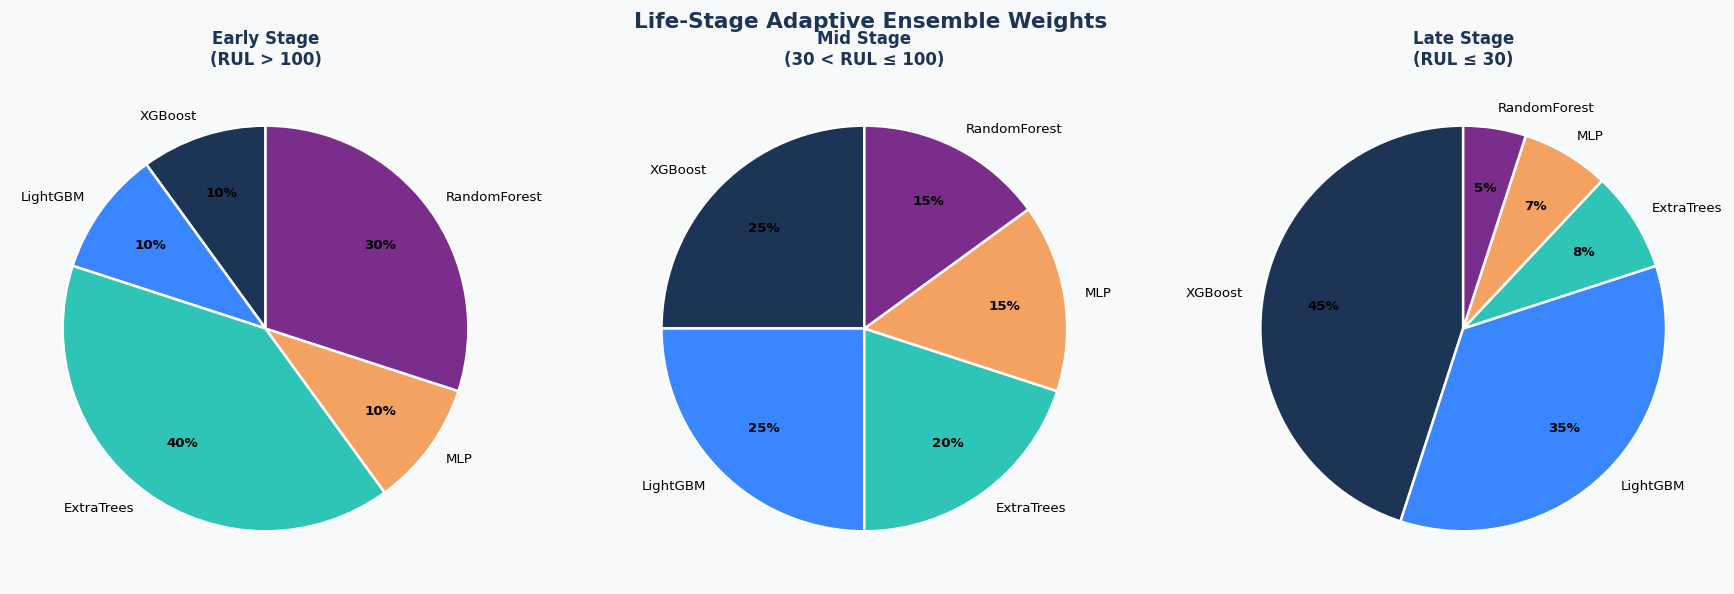

Saved: fig_adaptive_weights.png


In [19]:
# ── 7.4 Life-stage adaptive weight pie charts ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=PALETTE['bg'])
fig.suptitle('Life-Stage Adaptive Ensemble Weights',
             fontsize=13, fontweight='bold', color=PALETTE['primary'])

stage_info = [
    ('Early Stage\n(RUL > 100)', 'early'),
    ('Mid Stage\n(30 < RUL ≤ 100)', 'mid'),
    ('Late Stage\n(RUL ≤ 30)', 'late'),
]
slice_colors = ['#1C3557','#3A86FF','#2EC4B6','#F4A261','#7B2D8B']

for ax, (title, stage) in zip(axes, stage_info):
    weights = LIFE_STAGE_BIAS[stage]
    wedges, texts, autotexts = ax.pie(
        weights, labels=MODEL_NAMES, autopct='%1.0f%%',
        colors=slice_colors, startangle=90,
        pctdistance=0.70,
        textprops={'fontsize': 8},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight('bold')
    ax.set_title(title, fontweight='bold', fontsize=10,
                 color=PALETTE['primary'])

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_adaptive_weights.png', bbox_inches='tight')
plt.show()
print('Saved: fig_adaptive_weights.png')

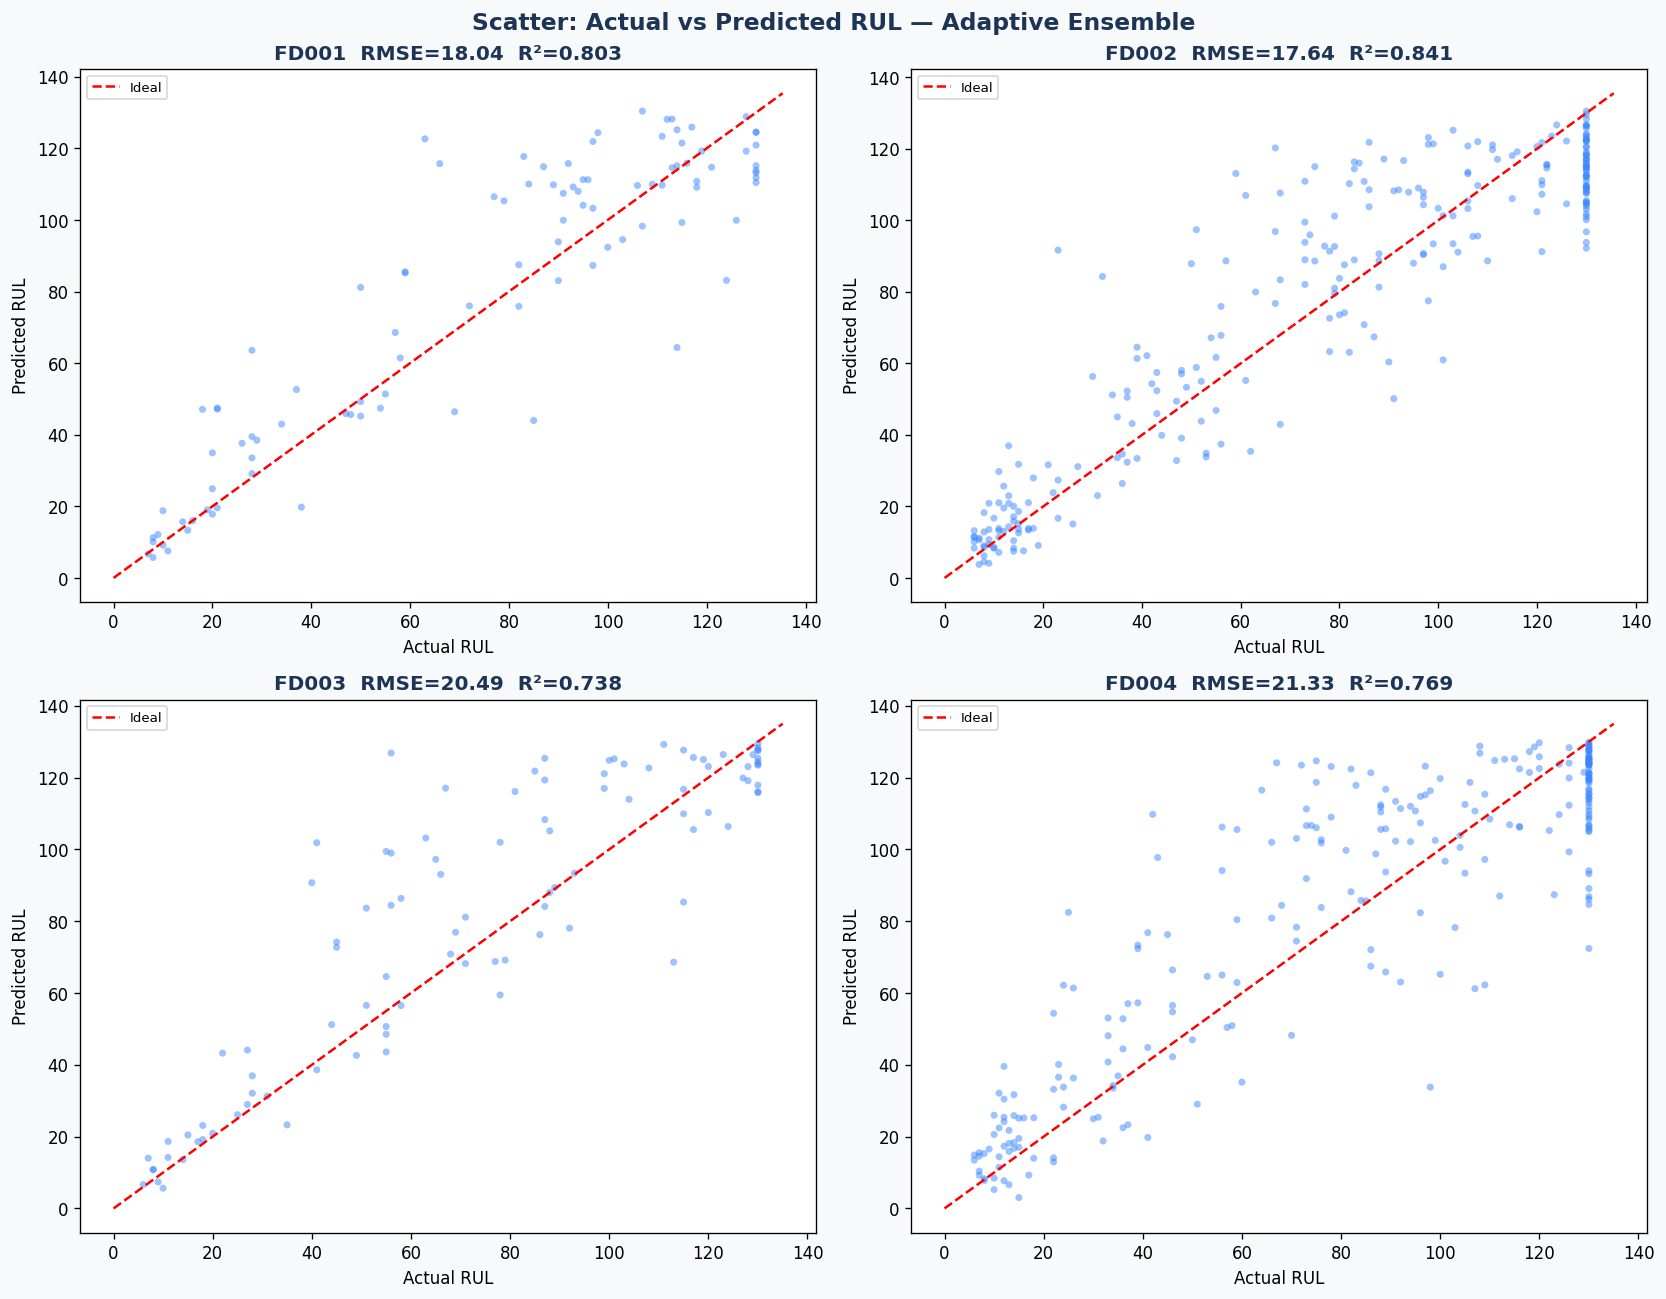

Saved: fig_scatter_actual_predicted.png


In [20]:
# ── 7.5 Scatter: Actual vs Predicted ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11), facecolor=PALETTE['bg'])
fig.suptitle('Scatter: Actual vs Predicted RUL — Adaptive Ensemble',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    y_true = results[s]['y_true']
    y_pred = results[s]['preds']['adaptive']
    rmse, r2 = results[s]['metrics']['Adaptive Ensemble']

    ax.scatter(y_true, y_pred, alpha=0.5, s=18,
               color=PALETTE['mid'], edgecolors='none')
    lim = max(y_true.max(), y_pred.max()) + 5
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Ideal')
    ax.set_xlabel('Actual RUL')
    ax.set_ylabel('Predicted RUL')
    ax.set_title(
        f'{s}  RMSE={rmse:.2f}  R²={r2:.3f}',
        fontweight='bold', color=PALETTE['primary']
    )
    ax.legend(fontsize=8)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_scatter_actual_predicted.png',
            bbox_inches='tight')
plt.show()
print('Saved: fig_scatter_actual_predicted.png')

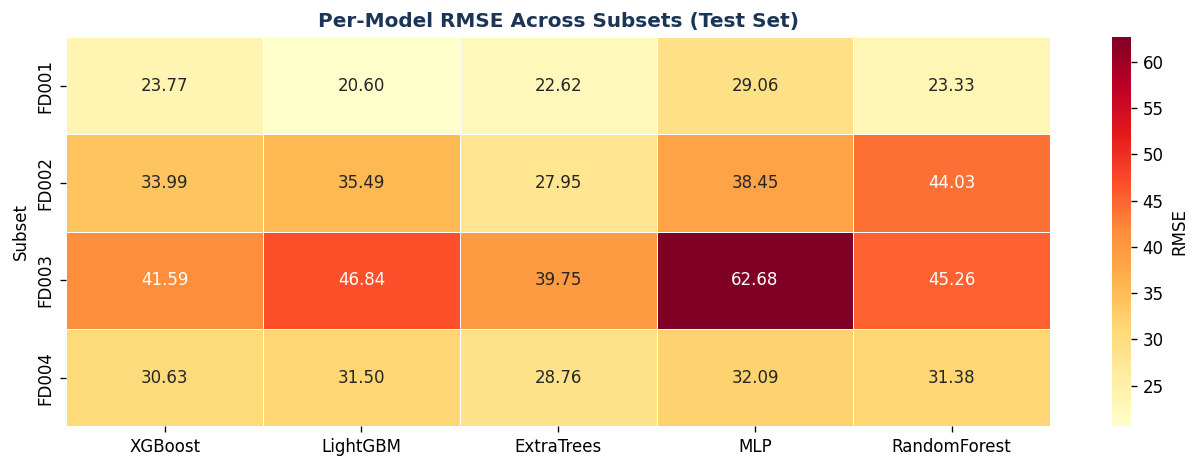

Saved: fig_model_rmse_heatmap.png


In [21]:
# ── 7.6 Per-model RMSE heatmap ──────────────────────────────────────
model_rmse_table = {m: [] for m in MODEL_NAMES}
for s in SUBSETS:
    te   = processed[s]['test']
    feat = processed[s]['features']
    y_t  = te['RUL'].values
    X_t  = te[feat].values
    c0   = list(ensemble_store[s].keys())[0]
    for m, mdl in ensemble_store[s][c0]['models'].items():
        p = mdl.predict(X_t)
        model_rmse_table[m].append(
            np.sqrt(mean_squared_error(y_t, p))
        )

heat_df = pd.DataFrame(model_rmse_table, index=SUBSETS)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'RMSE'})
ax.set_title('Per-Model RMSE Across Subsets (Test Set)',
             fontsize=12, fontweight='bold', color=PALETTE['primary'])
ax.set_ylabel('Subset')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_model_rmse_heatmap.png',
            bbox_inches='tight')
plt.show()
print('Saved: fig_model_rmse_heatmap.png')

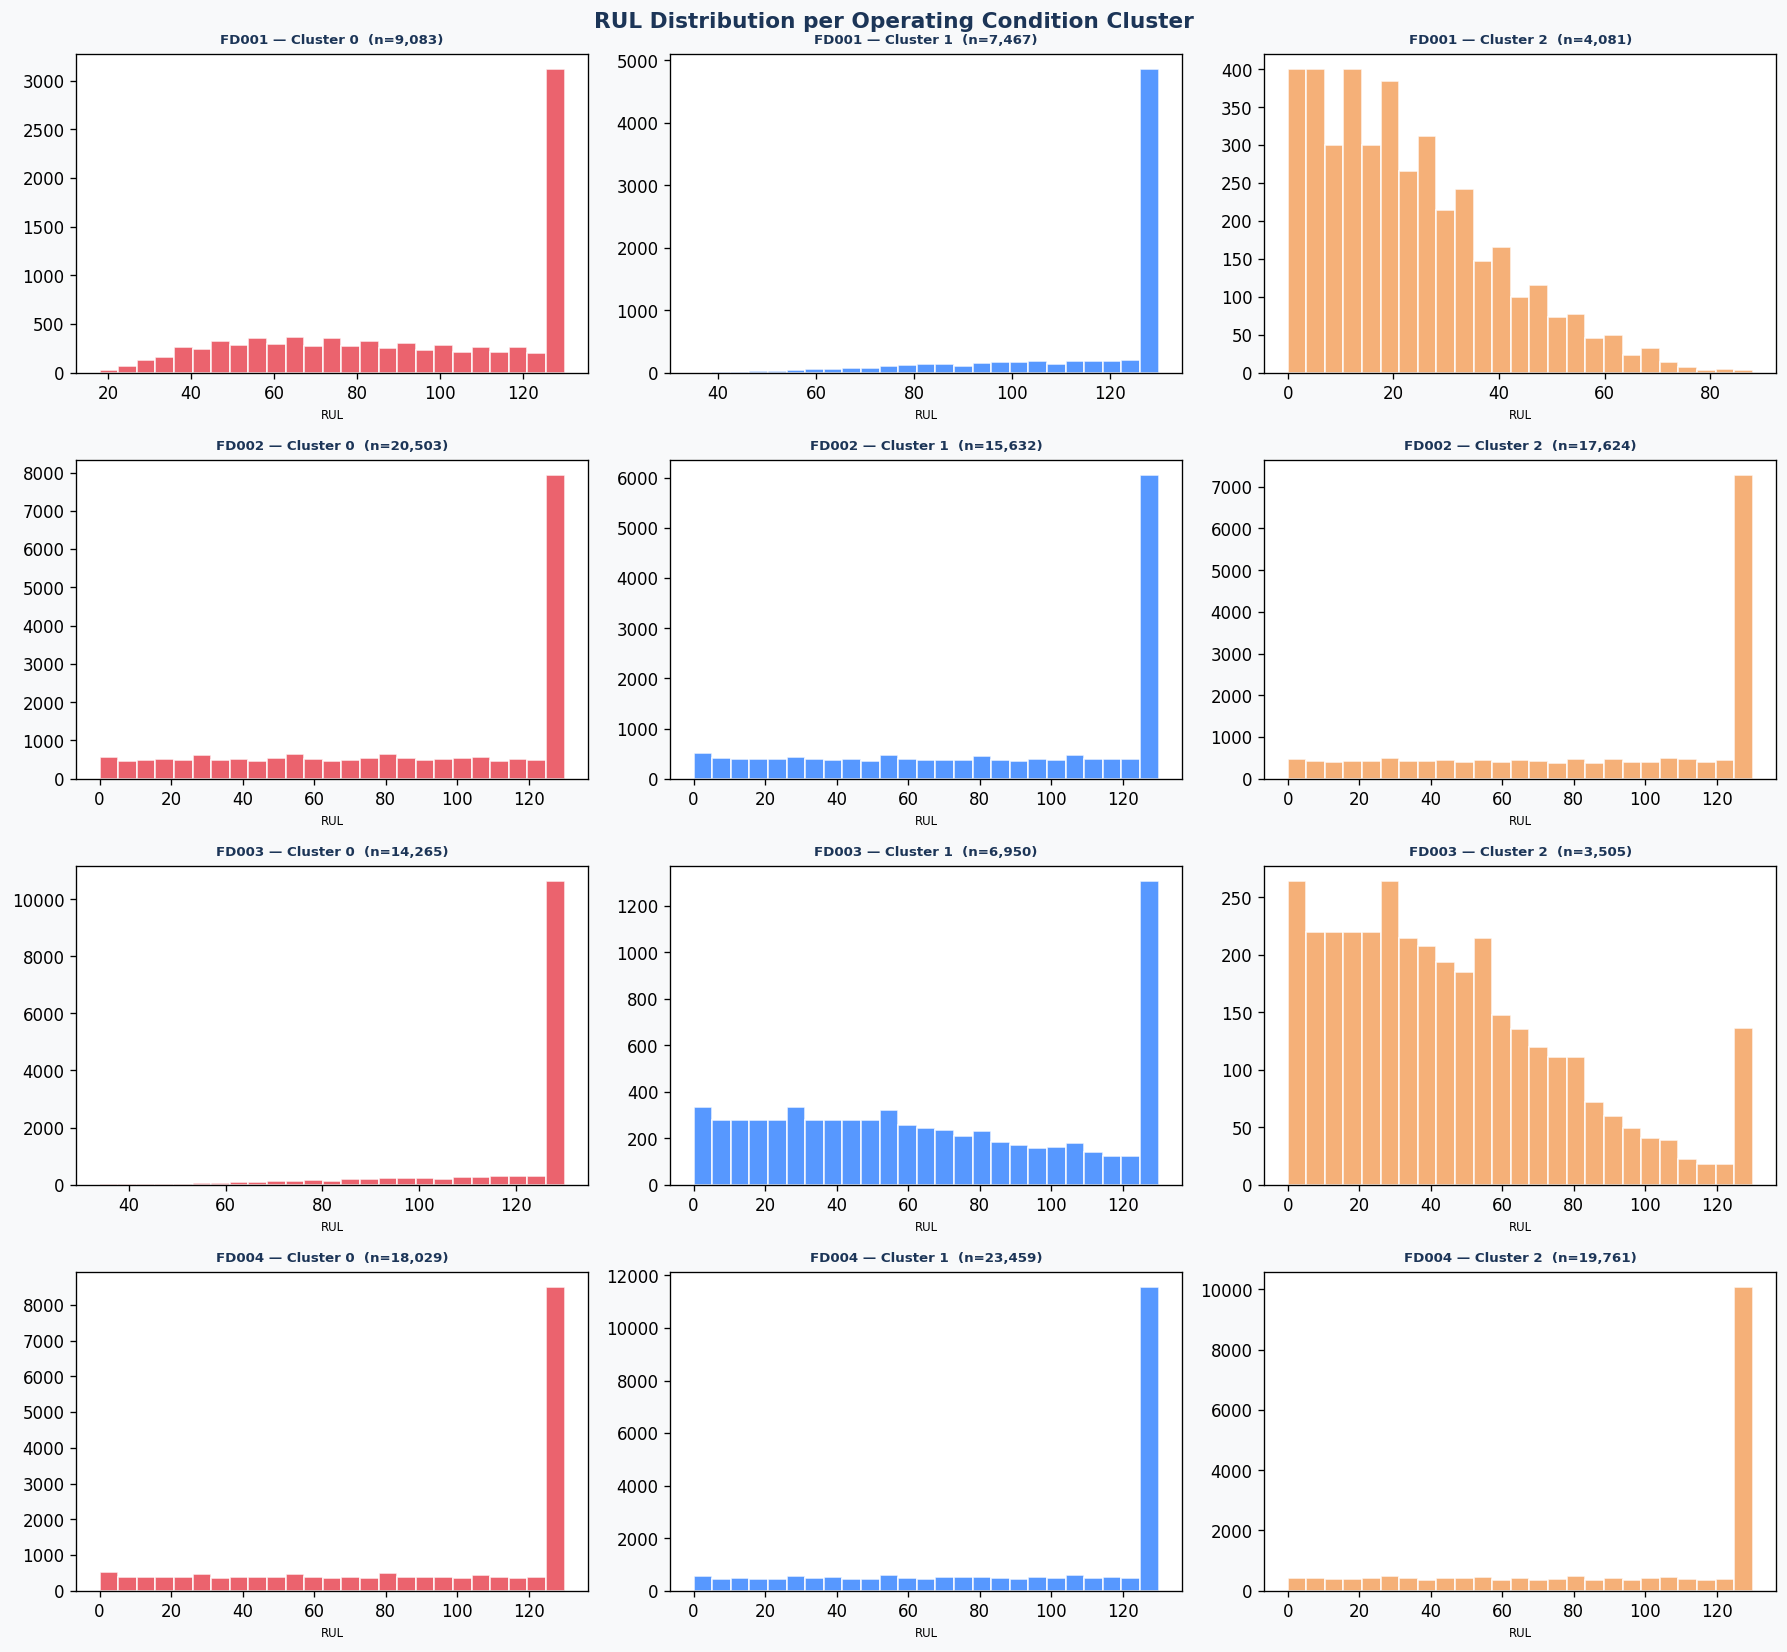

Saved: fig_cluster_rul_dist.png


In [22]:
# ── 7.7 Cluster RUL distributions — all subsets ────────────────────
fig, axes = plt.subplots(4, 3, figsize=(15, 14), facecolor=PALETTE['bg'])
fig.suptitle('RUL Distribution per Operating Condition Cluster',
             fontsize=13, fontweight='bold', color=PALETTE['primary'])
clr = [PALETTE['accent'], PALETTE['mid'], PALETTE['gold']]

for row, s in enumerate(SUBSETS):
    tr = processed[s]['train']
    for c in range(N_CLUSTERS):
        ax     = axes[row][c]
        subset = tr[tr['cluster'] == c]['RUL']
        ax.hist(subset, bins=25, color=clr[c],
                edgecolor='white', alpha=0.85)
        ax.set_title(f'{s} — Cluster {c}  (n={len(subset):,})',
                     fontsize=8, fontweight='bold',
                     color=PALETTE['primary'])
        ax.set_xlabel('RUL', fontsize=7)
        ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_cluster_rul_dist.png', bbox_inches='tight')
plt.show()
print('Saved: fig_cluster_rul_dist.png')

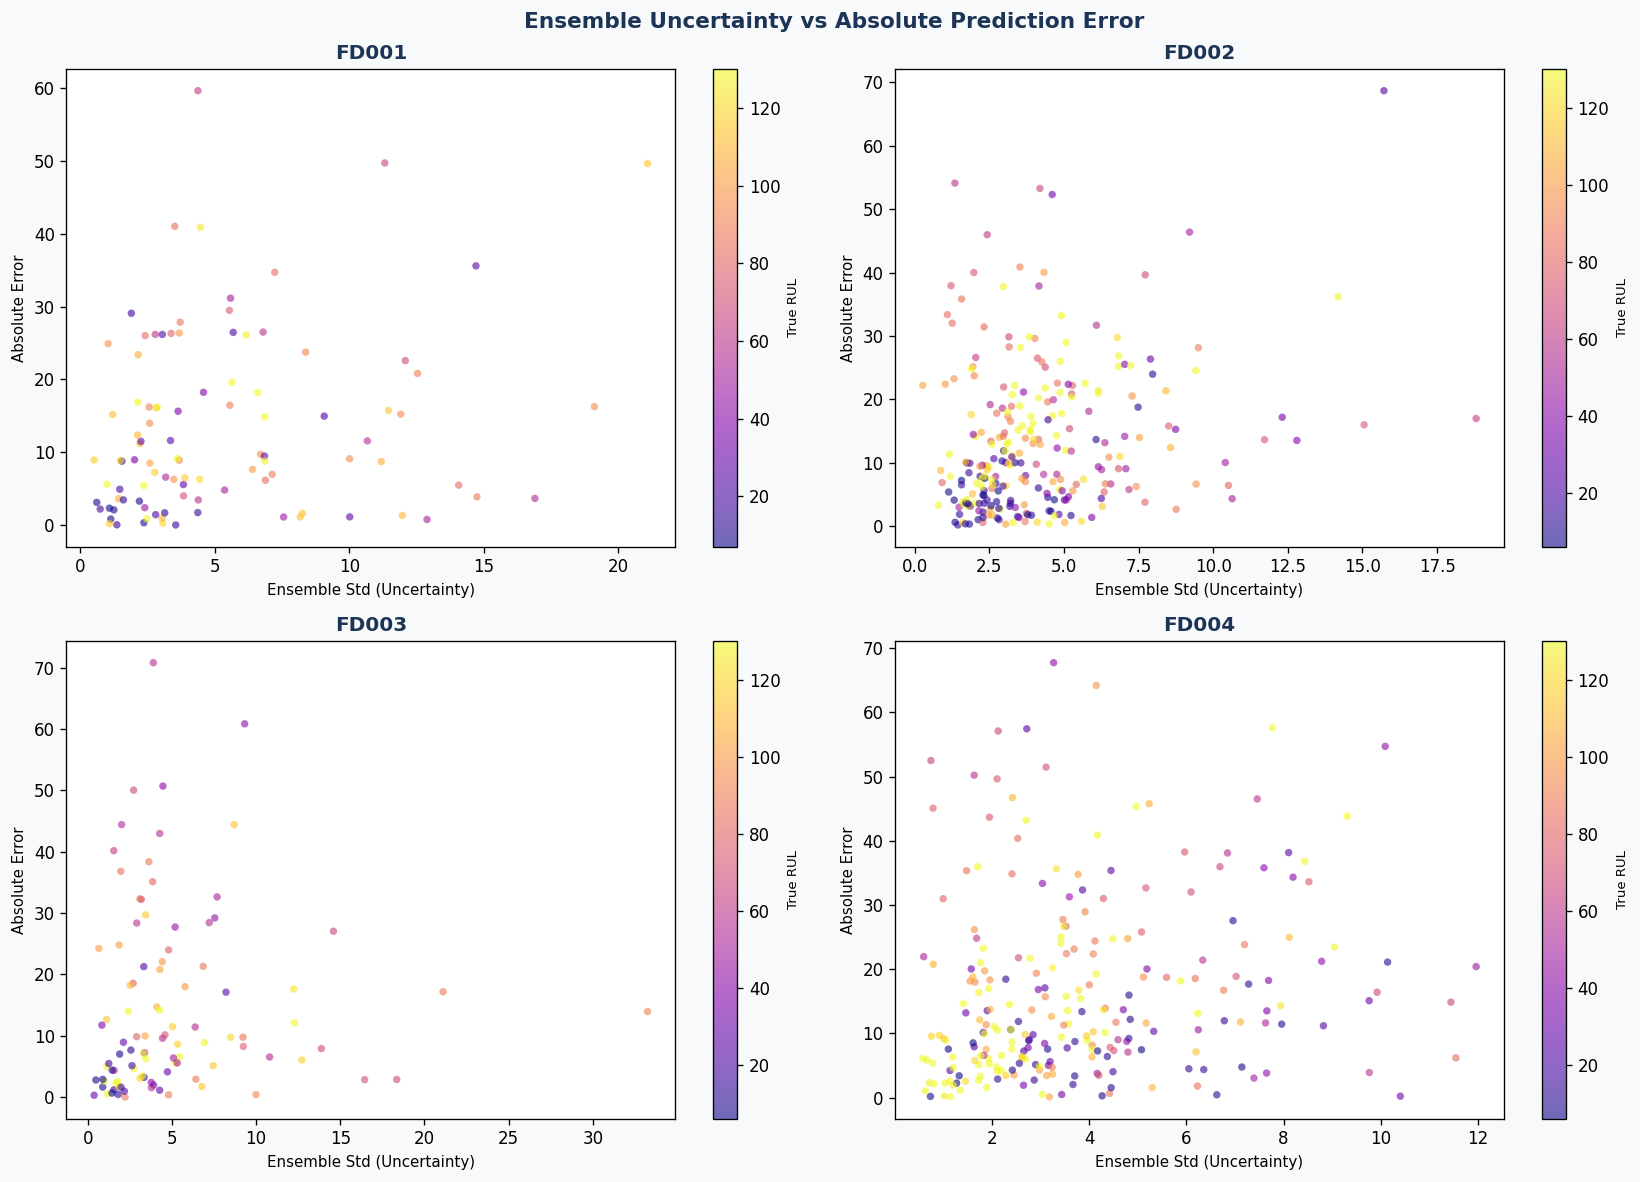

Saved: fig_uncertainty_vs_error.png


In [23]:
# ── 7.8 Uncertainty vs error — all subsets ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=PALETTE['bg'])
fig.suptitle('Ensemble Uncertainty vs Absolute Prediction Error',
             fontsize=13, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    y_true = results[s]['y_true']
    y_pred = results[s]['preds']['adaptive']
    std    = results[s]['preds']['std']
    error  = np.abs(y_true - y_pred)

    sc = ax.scatter(std, error, c=y_true, cmap='plasma',
                    alpha=0.6, s=20, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('True RUL', fontsize=8)
    ax.set_xlabel('Ensemble Std (Uncertainty)', fontsize=9)
    ax.set_ylabel('Absolute Error', fontsize=9)
    ax.set_title(s, fontweight='bold', color=PALETTE['primary'])
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_uncertainty_vs_error.png',
            bbox_inches='tight')
plt.show()
print('Saved: fig_uncertainty_vs_error.png')

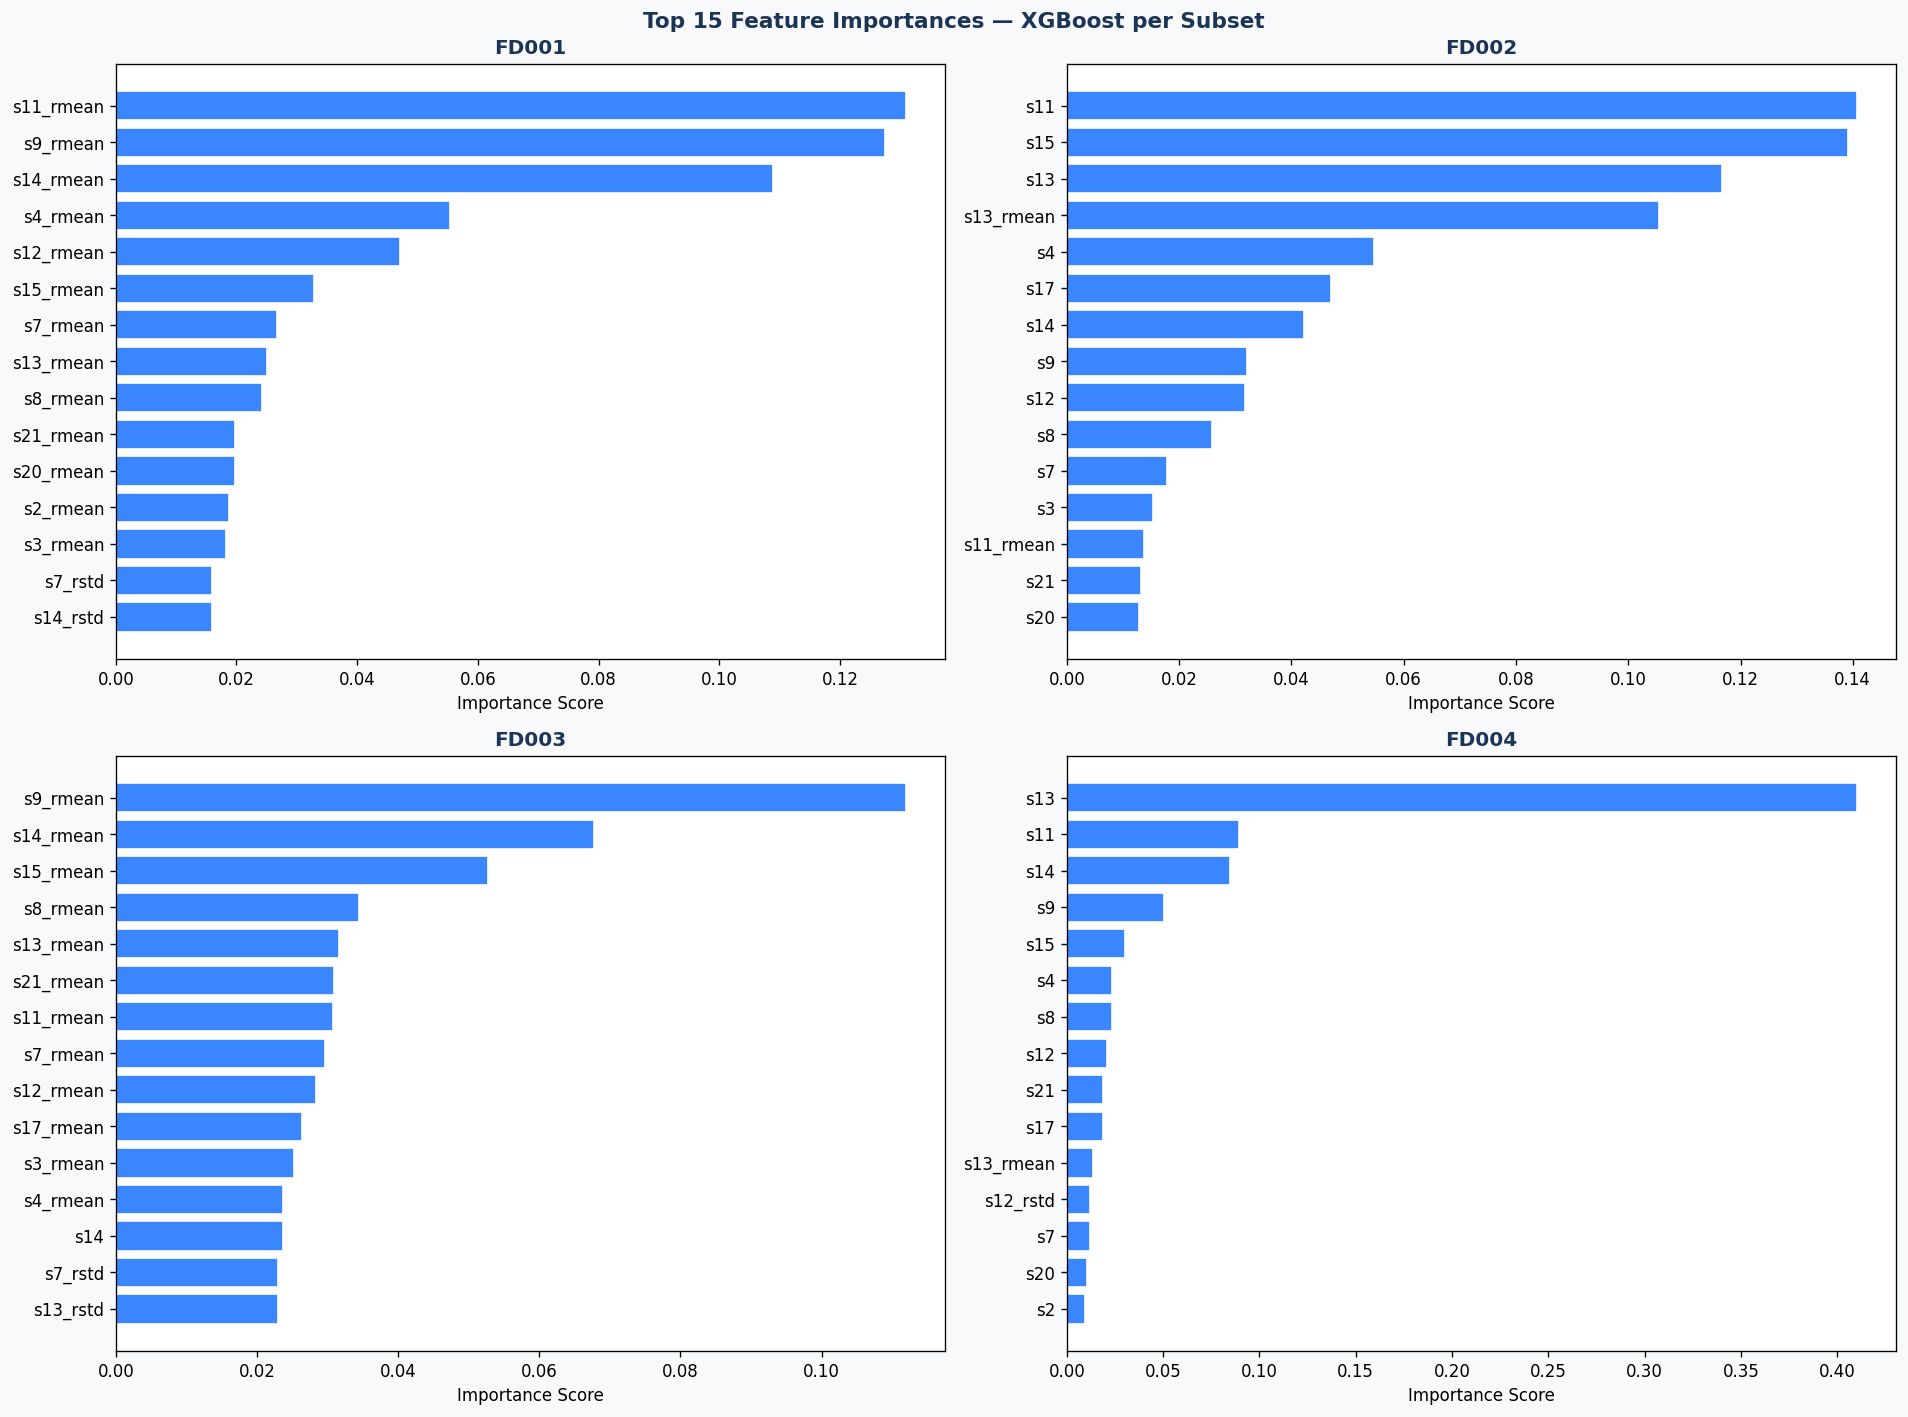

Saved: fig_feature_importance.png


In [24]:
# ── 7.9 Feature Importance (XGBoost, all subsets) ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=PALETTE['bg'])
fig.suptitle('Top 15 Feature Importances — XGBoost per Subset',
             fontsize=13, fontweight='bold', color=PALETTE['primary'])

for ax, s in zip(axes.flatten(), SUBSETS):
    c0          = list(ensemble_store[s].keys())[0]
    xgb_model   = ensemble_store[s][c0]['models']['XGBoost']
    feat_names  = processed[s]['features']
    importances = xgb_model.feature_importances_
    top_n = 15
    idx   = np.argsort(importances)[-top_n:]

    ax.barh([feat_names[i] for i in idx],
            importances[idx],
            color=PALETTE['mid'], edgecolor='white')
    ax.set_title(s, fontweight='bold', color=PALETTE['primary'])
    ax.set_xlabel('Importance Score')
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_feature_importance.png',
            bbox_inches='tight')
plt.show()
print('Saved: fig_feature_importance.png')

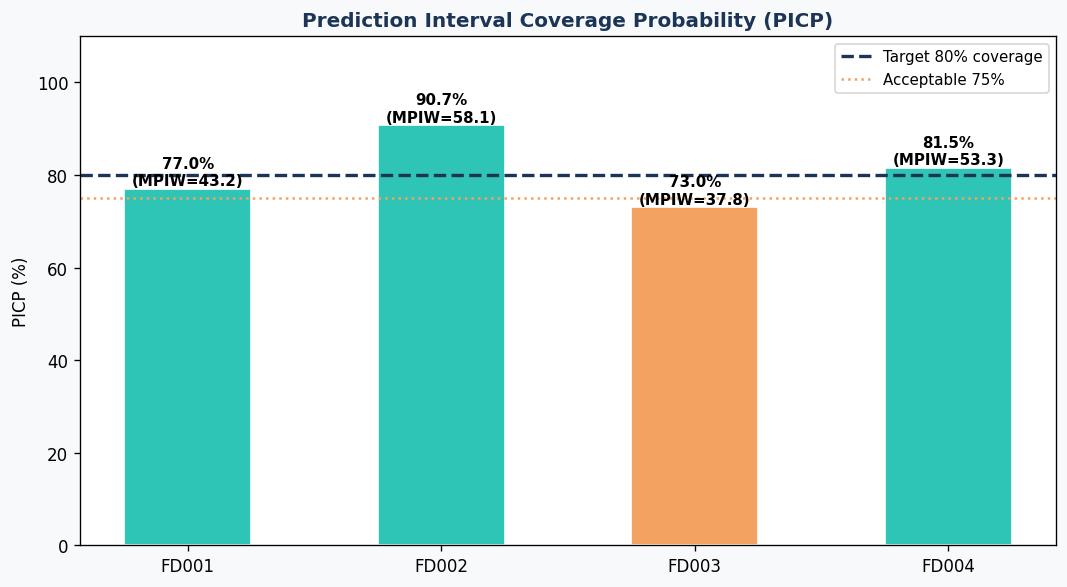

Saved: fig_picp_summary.png


In [25]:
# ── 7.10 PICP bar chart — all subsets ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor=PALETTE['bg'])
ax.set_facecolor('white')

picps  = [results[s]['picp'] for s in SUBSETS]
mpiws  = [results[s]['mpiw'] for s in SUBSETS]
colors = [PALETTE['green'] if p >= 75
          else PALETTE['gold'] if p >= 60
          else PALETTE['accent']
          for p in picps]

bars = ax.bar(SUBSETS, picps, color=colors,
              edgecolor='white', width=0.5)
ax.axhline(80, color=PALETTE['primary'], lw=2,
           linestyle='--', label='Target 80% coverage')
ax.axhline(75, color=PALETTE['gold'], lw=1.5,
           linestyle=':', label='Acceptable 75%')

for bar, val, mpiw in zip(bars, picps, mpiws):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{val:.1f}%\n(MPIW={mpiw:.1f})',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Prediction Interval Coverage Probability (PICP)',
             fontsize=12, fontweight='bold', color=PALETTE['primary'])
ax.set_ylabel('PICP (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_picp_summary.png', bbox_inches='tight')
plt.show()
print('Saved: fig_picp_summary.png')

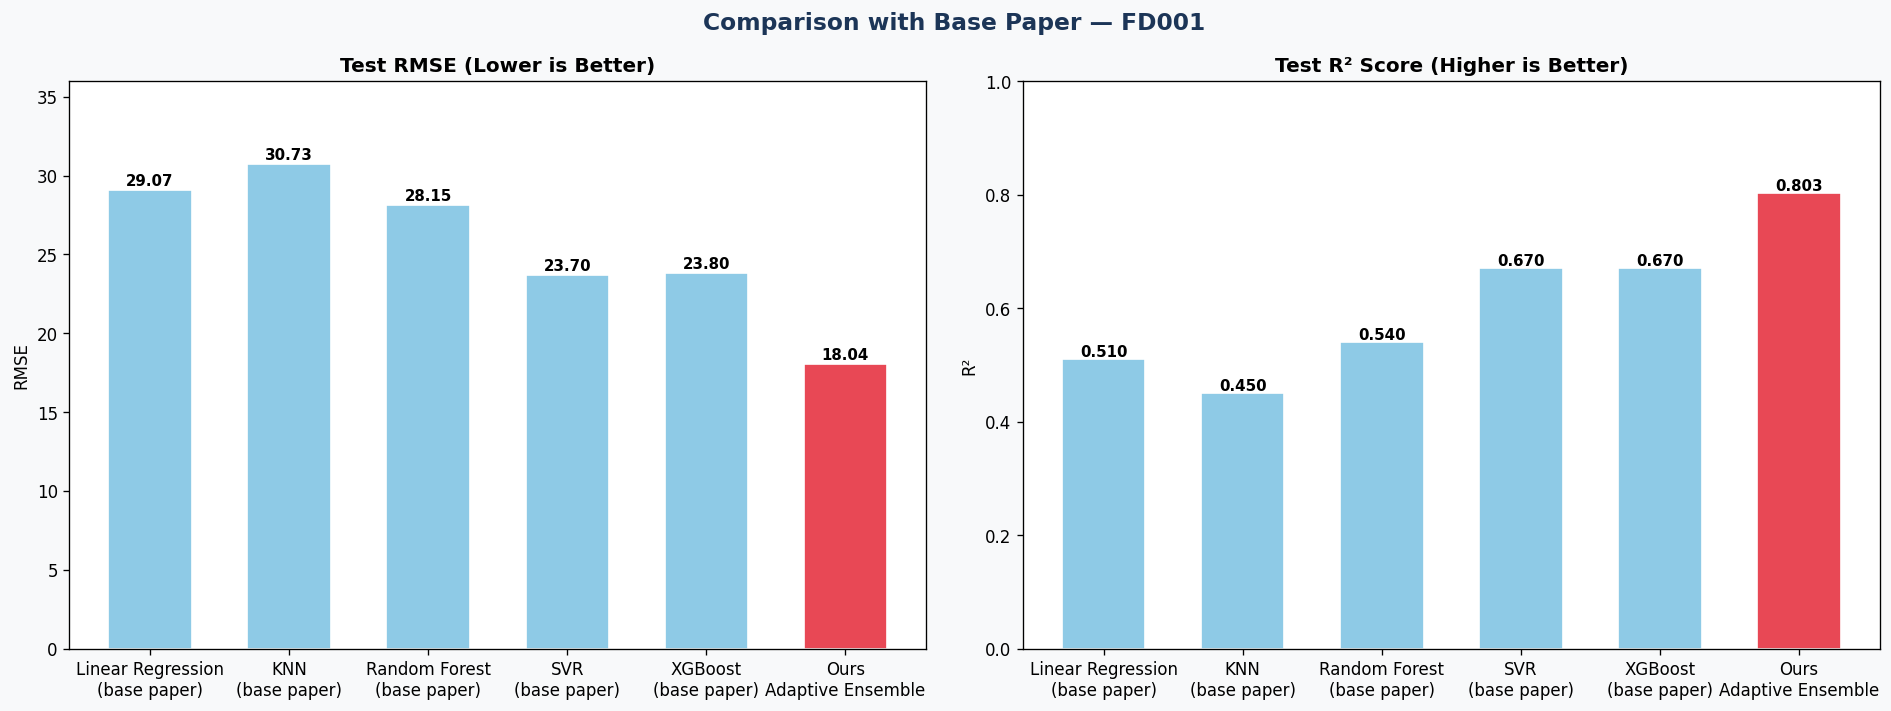

Saved: fig_comparison_baseline.png


In [26]:
# ── 7.11 Comparison with base paper (FD001) ─────────────────────────
adp_rmse = results['FD001']['metrics']['Adaptive Ensemble'][0]
adp_r2   = results['FD001']['metrics']['Adaptive Ensemble'][1]

comparison = pd.DataFrame([
    {'Method':'Linear Regression\n(base paper)', 'RMSE':29.07, 'R²':0.51},
    {'Method':'KNN\n(base paper)',                'RMSE':30.73, 'R²':0.45},
    {'Method':'Random Forest\n(base paper)',      'RMSE':28.15, 'R²':0.54},
    {'Method':'SVR\n(base paper)',                'RMSE':23.70, 'R²':0.67},
    {'Method':'XGBoost\n(base paper)',            'RMSE':23.80, 'R²':0.67},
    {'Method':'Ours\nAdaptive Ensemble',
     'RMSE':round(adp_rmse,3), 'R²':round(adp_r2,3)},
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                facecolor=PALETTE['bg'])
fig.suptitle('Comparison with Base Paper — FD001',
             fontsize=14, fontweight='bold', color=PALETTE['primary'])
bar_clrs = [PALETTE['light']] * 5 + [PALETTE['accent']]

bars = ax1.bar(comparison['Method'], comparison['RMSE'],
               color=bar_clrs, edgecolor='white', width=0.6)
for bar, val in zip(bars, comparison['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f'{val:.2f}',
             ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Test RMSE (Lower is Better)', fontweight='bold')
ax1.set_ylabel('RMSE')
ax1.set_ylim(0, 36)
ax1.set_facecolor('white')

bars2 = ax2.bar(comparison['Method'], comparison['R²'],
                color=bar_clrs, edgecolor='white', width=0.6)
for bar, val in zip(bars2, comparison['R²']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005, f'{val:.3f}',
             ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Test R² Score (Higher is Better)', fontweight='bold')
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1.0)
ax2.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/fig_comparison_baseline.png',
            bbox_inches='tight')
plt.show()
print('Saved: fig_comparison_baseline.png')

---
## Phase 8: Summary Results Tables

In [27]:
# ── Full results summary ────────────────────────────────────────────
rows = []
for s in SUBSETS:
    for method, (rmse, r2) in results[s]['metrics'].items():
        rows.append({'Subset':s, 'Method':method,
                     'RMSE':round(rmse,3), 'R²':round(r2,3)})
    rows.append({'Subset':s, 'Method':'PICP (80% PI)',
                 'RMSE':'—', 'R²':f"{results[s]['picp']:.1f}%"})
    rows.append({'Subset':s, 'Method':'MPIW (Interval Width)',
                 'RMSE':'—', 'R²':f"{results[s]['mpiw']:.2f}"})

summary_df = pd.DataFrame(rows)
print('\n════════════════════ RESULTS SUMMARY (Final) ════════════════════')
print(summary_df.to_string(index=False))
print('════════════════════════════════════════════════════════════════')


════════════════════ RESULTS SUMMARY (Final) ════════════════════
Subset                   Method    RMSE     R²
 FD001        Adaptive Ensemble  18.036  0.803
 FD001           Simple Average   17.93  0.806
 FD001 Best Single (ExtraTrees)  18.612  0.791
 FD001            PICP (80% PI)       —  77.0%
 FD001    MPIW (Interval Width)       —  43.16
 FD002        Adaptive Ensemble   17.64  0.841
 FD002           Simple Average  17.664  0.841
 FD002        Best Single (MLP)  17.467  0.844
 FD002            PICP (80% PI)       —  90.7%
 FD002    MPIW (Interval Width)       —  58.10
 FD003        Adaptive Ensemble  20.489  0.738
 FD003           Simple Average  20.674  0.734
 FD003 Best Single (ExtraTrees)  20.342  0.742
 FD003            PICP (80% PI)       —  73.0%
 FD003    MPIW (Interval Width)       —  37.80
 FD004        Adaptive Ensemble  21.333  0.769
 FD004           Simple Average  21.348  0.769
 FD004        Best Single (MLP)  21.436  0.767
 FD004            PICP (80% PI)       — 

In [28]:
# ── Comparison with base paper ──────────────────────────────────────
adp_rmse     = results['FD001']['metrics']['Adaptive Ensemble'][0]
adp_r2       = results['FD001']['metrics']['Adaptive Ensemble'][1]
improve_rmse = ((23.80 - adp_rmse) / 23.80) * 100
improve_r2   = adp_r2 - 0.67

comp_rows = [
    {'Method':'Linear Regression (base paper)', 'Test RMSE':29.07, 'Test R²':0.510},
    {'Method':'KNN (base paper)',                'Test RMSE':30.73, 'Test R²':0.450},
    {'Method':'Random Forest (base paper)',      'Test RMSE':28.15, 'Test R²':0.540},
    {'Method':'SVR (base paper)',                'Test RMSE':23.70, 'Test R²':0.670},
    {'Method':'XGBoost (base paper)',            'Test RMSE':23.80, 'Test R²':0.670},
    {'Method':'▶ Adaptive Ensemble (Ours)',
     'Test RMSE':round(adp_rmse,3),
     'Test R²':round(adp_r2,3)},
]
comp_df = pd.DataFrame(comp_rows)

print('\n════════════ COMPARISON WITH BASE PAPER (FD001) ════════════')
print(comp_df.to_string(index=False))
print(f'\n  RMSE improvement over XGBoost baseline : {improve_rmse:.1f}%')
print(f'  R²   improvement over XGBoost baseline : +{improve_r2:.3f}')
print('════════════════════════════════════════════════════════════')


════════════ COMPARISON WITH BASE PAPER (FD001) ════════════
                        Method  Test RMSE  Test R²
Linear Regression (base paper)     29.070    0.510
              KNN (base paper)     30.730    0.450
    Random Forest (base paper)     28.150    0.540
              SVR (base paper)     23.700    0.670
          XGBoost (base paper)     23.800    0.670
    ▶ Adaptive Ensemble (Ours)     18.036    0.803

  RMSE improvement over XGBoost baseline : 24.2%
  R²   improvement over XGBoost baseline : +0.133
════════════════════════════════════════════════════════════


In [29]:
# ── Adaptive vs Simple Average gap summary ─────────────────────────
print('\n══════ Adaptive vs Simple Average — RMSE Gap ══════')
print(f'{"Subset":<8} {"Adaptive":>10} {"Simple":>10}'
      f' {"Gap":>8} {"Winner":>12}')
print('─' * 52)
for s in SUBSETS:
    adp    = results[s]['metrics']['Adaptive Ensemble'][0]
    avg    = results[s]['metrics']['Simple Average'][0]
    gap    = avg - adp
    winner = 'Adaptive' if gap > 0 else 'Simple'
    print(f'{s:<8} {adp:>10.3f} {avg:>10.3f}'
          f' {gap:>+8.3f} {winner:>12}')
print('══════════════════════════════════════════════════')


══════ Adaptive vs Simple Average — RMSE Gap ══════
Subset     Adaptive     Simple      Gap       Winner
────────────────────────────────────────────────────
FD001        18.036     17.930   -0.107       Simple
FD002        17.640     17.664   +0.024     Adaptive
FD003        20.489     20.674   +0.185     Adaptive
FD004        21.333     21.348   +0.015     Adaptive
══════════════════════════════════════════════════


---
## Phase 9: Save All Four Subset Pipelines

In [30]:
for s in SUBSETS:
    save_obj = {
        'ensemble_store' : ensemble_store[s],
        'cluster_pipe'   : cluster_pipes[s],
        'scaler'         : processed[s]['scaler'],
        'feature_cols'   : processed[s]['features'],
        'sensors'        : processed[s]['sensors'],
        'n_clusters'     : N_CLUSTERS,
        'rul_threshold'  : RUL_THRESHOLD,
        'model_names'    : MODEL_NAMES,
        'life_stage_bias': LIFE_STAGE_BIAS,
        'bias_alpha'     : BIAS_ALPHA,
        'version'        : 'v3.0-kaggle-final',
        'results_summary': {
            'adaptive_rmse': results[s]['metrics']['Adaptive Ensemble'][0],
            'adaptive_r2'  : results[s]['metrics']['Adaptive Ensemble'][1],
            'picp'         : results[s]['picp'],
            'mpiw'         : results[s]['mpiw'],
        }
    }
    fname = f'{OUTPUT_PATH}/rul_pipeline_final_{s}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(save_obj, f)
    size_kb = os.path.getsize(fname) / 1024
    print(f'Saved rul_pipeline_final_{s}.pkl  ({size_kb:.0f} KB)')

print('\n🎉 All 4 pipelines saved to /kaggle/working/')
print('   Download them from the Output tab on the right sidebar.')

Saved rul_pipeline_final_FD001.pkl  (227637 KB)
Saved rul_pipeline_final_FD002.pkl  (618509 KB)
Saved rul_pipeline_final_FD003.pkl  (233053 KB)
Saved rul_pipeline_final_FD004.pkl  (625290 KB)

🎉 All 4 pipelines saved to /kaggle/working/
   Download them from the Output tab on the right sidebar.


---
## Phase 10: Single Engine Inference

In [31]:
def predict_single_engine(engine_id, subset='FD001',
                           data_path=DATA_PATH,
                           output_path=OUTPUT_PATH,
                           conformal_quantile=0.85):
    """
    Load saved pipeline and predict RUL for one engine.
    Uses the last available cycle of that engine.
    """
    with open(f'{output_path}/rul_pipeline_final_{subset}.pkl', 'rb') as f:
        pipe = pickle.load(f)

    feat_cols = pipe['feature_cols']
    sensors   = pipe['sensors']
    scaler    = pipe['scaler']
    pca       = pipe['cluster_pipe']['pca']
    km        = pipe['cluster_pipe']['km']
    ens_store = pipe['ensemble_store']

    raw = pd.read_csv(
        os.path.join(data_path, f'test_{subset}.txt'),
        sep=r'\s+', header=None, names=COL_NAMES
    )
    eng  = raw[raw['engine_id'] == engine_id].copy()
    eng  = add_rolling_features(eng, sensors)
    last = eng.tail(1).copy()
    last[feat_cols] = scaler.transform(last[feat_cols])

    X_pca   = pca.transform(last[feat_cols].values)
    cluster = int(km.predict(X_pca)[0])
    if cluster not in ens_store:
        cluster = list(ens_store.keys())[0]

    ens    = ens_store[cluster]
    models = ens['models']
    vw     = ens['val_weights']
    cal_q  = float(np.quantile(ens['cal_residuals'], conformal_quantile))

    X_in  = last[feat_cols].values
    preds = {m: float(models[m].predict(X_in)) for m in models}
    p_arr = np.array([preds[m] for m in MODEL_NAMES])
    avg_p = float(np.mean(p_arr))
    stage = get_life_stage(avg_p)
    w     = compute_adaptive_weight(vw, stage)
    final = float(np.dot(w, p_arr))
    lower = final - cal_q
    upper = final + cal_q

    print(f'\n══════════════════════════════════════════')
    print(f'  Engine  : {engine_id}  |  Subset: {subset}')
    print(f'  Cluster : {cluster}  |  Life stage: {stage.upper()}')
    print(f'──────────────────────────────────────────')
    print(f'  Individual predictions:')
    for m, p in preds.items():
        w_val = w[MODEL_NAMES.index(m)]
        print(f'    {m:15s}: {p:6.1f} cycles  (weight={w_val:.2f})')
    print(f'──────────────────────────────────────────')
    print(f'  Predicted RUL   : {final:.1f} cycles')
    print(f'  Lower (P10)     : {lower:.1f} cycles')
    print(f'  Upper (P90)     : {upper:.1f} cycles')
    print(f'  Uncertainty ±   : {cal_q:.1f} cycles')
    print(f'══════════════════════════════════════════')

    return {'rul':final, 'lower':lower, 'upper':upper,
            'cluster':cluster, 'stage':stage}


# Test on one engine from each subset
_ = predict_single_engine(engine_id=1,  subset='FD001')
_ = predict_single_engine(engine_id=5,  subset='FD002')
_ = predict_single_engine(engine_id=10, subset='FD003')
_ = predict_single_engine(engine_id=3,  subset='FD004')


══════════════════════════════════════════
  Engine  : 1  |  Subset: FD001
  Cluster : 1  |  Life stage: EARLY
──────────────────────────────────────────
  Individual predictions:
    XGBoost        :  127.7 cycles  (weight=0.18)
    LightGBM       :  129.8 cycles  (weight=0.18)
    ExtraTrees     :  126.8 cycles  (weight=0.30)
    MLP            :  134.3 cycles  (weight=0.08)
    RandomForest   :  126.7 cycles  (weight=0.25)
──────────────────────────────────────────
  Predicted RUL   : 128.1 cycles
  Lower (P10)     : 111.0 cycles
  Upper (P90)     : 145.2 cycles
  Uncertainty ±   : 17.1 cycles
══════════════════════════════════════════

══════════════════════════════════════════
  Engine  : 5  |  Subset: FD002
  Cluster : 0  |  Life stage: LATE
──────────────────────────────────────────
  Individual predictions:
    XGBoost        :    7.5 cycles  (weight=0.28)
    LightGBM       :    9.1 cycles  (weight=0.24)
    ExtraTrees     :   16.2 cycles  (weight=0.16)
    MLP            :  